# Player Market Value Prediction
Predicting end-of-season market value from in-season performance statistics

This notebook fits three regression models. OLS, Ridge, and Random Forest on the Big 5 European football dataset.
Models are run for:
- Overall (all players, all leagues)
- Per league (Premier League, La Liga, Bundesliga, Serie A, Ligue 1)
- Per position (Goalkeeper, Defender, Midfielder, Forward)

No prior market value is used, only in-season statistics, player attributes, and team context.

## 1. Imports & Configuration

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 12, 'axes.labelsize': 11})

DATA_PATH = '../data/processed/player_db_enriched.csv'
OUT_PATH = '../outputs/model_results'
PKL_PATH = None
os.makedirs(OUT_PATH, exist_ok=True)

## 2. Data Loading & Feature Engineering

In [78]:
raw = pd.read_csv(DATA_PATH)
print(f"Raw dataset: {raw.shape[0]:,} rows, {raw.shape[1]} columns")
print(f"Seasons: {sorted(raw['season'].unique())}")
print(f"Leagues: {raw['league_comp'].unique().tolist()}")
print(f"Positions: {raw['position'].value_counts().to_dict()}")

Raw dataset: 13,605 rows, 50 columns
Seasons: ['2020-2021', '2021-2022', '2022-2023', '2023-2024', '2024-2025']
Leagues: ['it Serie A', 'eng Premier League', 'fr Ligue 1', 'de Bundesliga', 'es La Liga']
Positions: {'MF': 4175, 'DF': 3448, 'FW': 1778, 'MF/FW': 1038, 'GK': 1030, 'FW/MF': 810, 'DF/MF': 764, 'MF/DF': 548, 'DF/FW': 12, 'FW/DF': 2}


In [40]:
def prepare_data(df_in):
    df = df_in.copy()
    df = df.dropna(subset=['market_value_end'])
    df['log_mv'] = np.log1p(df['market_value_end'])
    pos_map = {
        'GK':0, 'DF':1,'DF,MF':1,'DF,FW':1,
        'MF':2,'MF,DF':2,'MF,FW':2,'FW,MF':2,
        'FW':3,'FW,DF':3
    }
    df['pos_enc']    = df['position'].map(pos_map).fillna(2)
    league_map = {'eng Premier League':1,'es La Liga':2,'de Bundesliga':3,
                  'it Serie A':4,'fr Ligue 1':5}
    df['league_enc'] = df['league_comp'].map(league_map).fillna(3)
    season_map = {'2020-2021':0,'2021-2022':1,'2022-2023':2,'2023-2024':3,'2024-2025':4}
    df['season_enc'] = df['season'].map(season_map).fillna(2)
    df['Age']   = df['Age'].fillna(df['Age'].median())
    df['age_sq'] = df['Age'] ** 2
    df['rating_imp'] = df['rating'].copy()
    for p in df['pos_enc'].unique():
        mask = df['pos_enc'] == p
        med  = df.loc[mask, 'rating'].median()
        df.loc[mask & df['rating'].isna(), 'rating_imp'] = med
    df['rating_imp'] = df['rating_imp'].fillna(df['rating'].median())
    return df

df = prepare_data(raw)
print(f"After dropping missing market values: {len(df):,} rows")
print(f"Log market value range: {df['log_mv'].min():.2f} to {df['log_mv'].max():.2f}")

After dropping missing market values: 12,938 rows
Log market value range: 11.51 to 19.11


In [41]:
BASE = ['Age','age_sq','appearances','minutes','goals','assists','G+A','CrdY','CrdR',
        'Gls_90','Ast_90','G+A_90','xG90','xA90','xGChain90','xGBuildup90',
        'rating_imp','team_finishing_pos','season_enc']

OVERALL_FEATS  = BASE + ['pos_enc','league_enc']
PER_LEAGUE_FEATS = BASE + ['pos_enc']
PER_POS_BASE   = BASE + ['league_enc']

GK_FEATS = ['Age','age_sq','appearances','minutes',
            'gk_goals_conceded_per90','gk_clean_sheet_pct','gk_win_rate',
            'rating_imp','CrdY','team_finishing_pos','league_enc','season_enc']

DF_FEATS = ['Age','age_sq','appearances','minutes',
            'def_goals_conceded_per90','def_clean_sheet_pct','def_win_rate',
            'assists','Ast_90','xGBuildup90',
            'rating_imp','CrdY','CrdR','team_finishing_pos','league_enc','season_enc']

MF_FEATS = PER_POS_BASE
FW_FEATS = PER_POS_BASE

LABELS = {
    'Age':'Age', 'age_sq':'AgeÂ²', 'appearances':'Appearances',
    'minutes':'Minutes Played', 'goals':'Goals', 'assists':'Assists',
    'G+A':'Goals + Assists', 'CrdY':'Yellow Cards', 'CrdR':'Red Cards',
    'Gls_90':'Goals / 90', 'Ast_90':'Assists / 90', 'G+A_90':'G+A / 90',
    'xG90':'xG / 90', 'xA90':'xA / 90',
    'xGChain90':'xG Chain / 90', 'xGBuildup90':'xG Buildup / 90',
    'rating_imp':'Player Rating', 'team_finishing_pos':'Team Finishing Pos',
    'season_enc':'Season', 'pos_enc':'Position', 'league_enc':'League',
    'gk_goals_conceded_per90':'Goals Conceded / 90 (GK)',
    'gk_clean_sheet_pct':'Clean Sheet % (GK)',
    'gk_win_rate':'Win Rate (GK)',
    'def_goals_conceded_per90':'Goals Conceded / 90 (Def)',
    'def_clean_sheet_pct':'Clean Sheet % (Def)',
    'def_win_rate':'Win Rate (Def)',
}

def lbl(f): return LABELS.get(f, f)

print("Feature sets defined:")
print(f"Overall: {len(OVERALL_FEATS)} features")
print(f"Per-league: {len(PER_LEAGUE_FEATS)} features")
print(f"GK: {len(GK_FEATS)} features")
print(f"Defender: {len(DF_FEATS)} features")
print(f"MF / FW: {len(MF_FEATS)} features")

Feature sets defined:
Overall: 21 features
Per-league: 20 features
GK: 12 features
Defender: 16 features
MF / FW: 20 features


## 3. Exploratory Data Analysis

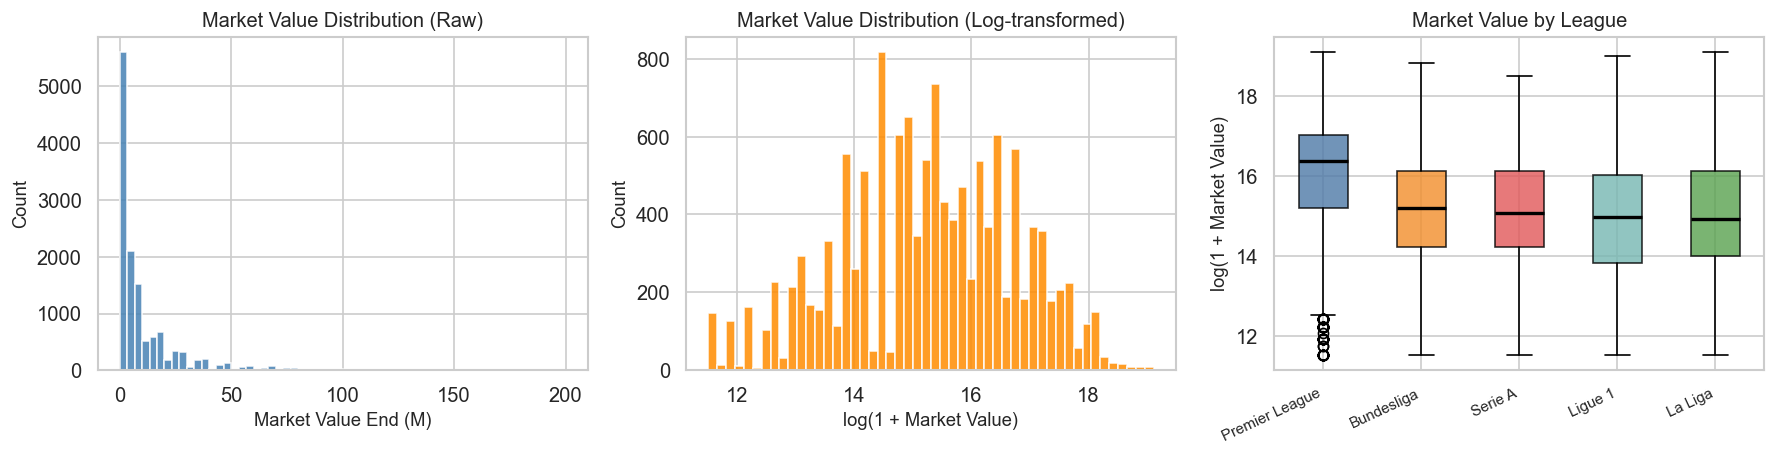

Saved eda_distributions.png


In [79]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['market_value_end'].dropna() / 1e6, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Market Value End (M)')
axes[0].set_ylabel('Count')
axes[0].set_title('Market Value Distribution (Raw)')

axes[1].hist(df['log_mv'], bins=50, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('log(1 + Market Value)')
axes[1].set_ylabel('Count')
axes[1].set_title('Market Value Distribution (Log-transformed)')

order = df.groupby('league_comp')['log_mv'].median().sort_values(ascending=False).index
league_names = {'eng Premier League':'Premier League','es La Liga':'La Liga',
                'de Bundesliga':'Bundesliga','it Serie A':'Serie A','fr Ligue 1':'Ligue 1'}
data_by_league = [df.loc[df['league_comp']==l, 'log_mv'].values for l in order]
bp = axes[2].boxplot(data_by_league, patch_artist=True, widths=0.5,
                     medianprops=dict(color='black', linewidth=2))
colors = ['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.8)
axes[2].set_xticklabels([league_names.get(l,l) for l in order], rotation=25, ha='right', fontsize=9)
axes[2].set_ylabel('log(1 + Market Value)')
axes[2].set_title('Market Value by League')

plt.tight_layout()
plt.savefig(f'{OUT_PATH}/eda_distributions.png', bbox_inches='tight')
plt.show()
print("Saved eda_distributions.png")

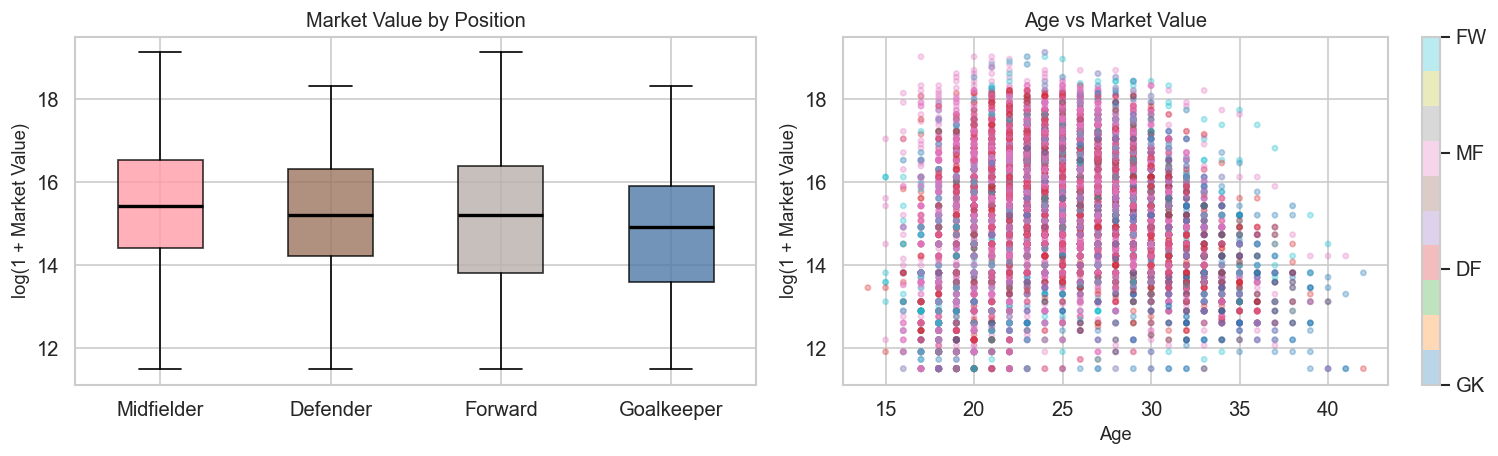

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

pos_labels = {0:'Goalkeeper', 1:'Defender', 2:'Midfielder', 3:'Forward'}
order_pos = df.groupby('pos_enc')['log_mv'].median().sort_values(ascending=False).index
data_by_pos = [df.loc[df['pos_enc']==p, 'log_mv'].values for p in order_pos]
bp2 = axes[0].boxplot(data_by_pos, patch_artist=True, widths=0.5,
                      medianprops=dict(color='black', linewidth=2))
pos_colors = ['#ff9da7','#9c755f','#bab0ac','#4e79a7']
for patch, color in zip(bp2['boxes'], pos_colors):
    patch.set_facecolor(color); patch.set_alpha(0.8)
axes[0].set_xticklabels([pos_labels.get(p,'?') for p in order_pos])
axes[0].set_ylabel('log(1 + Market Value)')
axes[0].set_title('Market Value by Position')

sc = axes[1].scatter(df['Age'], df['log_mv'], c=df['pos_enc'], cmap='tab10',
                     alpha=0.3, s=10, vmin=0, vmax=3)
axes[1].set_xlabel('Age')
axes[1].set_ylabel('log(1 + Market Value)')
axes[1].set_title('Age vs Market Value')
cbar = plt.colorbar(sc, ax=axes[1])
cbar.set_ticks([0,1,2,3]); cbar.set_ticklabels(['GK','DF','MF','FW'])

plt.tight_layout()
plt.savefig(f'{OUT_PATH}/eda_position_age.png', bbox_inches='tight')
plt.show()

## 4. Model Implementations, NumPy only

Three models are implemented from scratch using NumPy:

1. OLS Linear Regression
2. Ridge Regression
3. Random Forest

Feature importance:
- OLS/Ridge: absolute normalised coefficients
- Random Forest: variance-reduction impurity + permutation importance


In [44]:
def r2(yt, yp):
    ss_res = np.sum((yt - yp) ** 2)
    ss_tot = np.sum((yt - yt.mean()) ** 2)
    return 1 - ss_res / max(ss_tot, 1e-12)

def rmse(yt, yp):
    return np.sqrt(np.mean((yt - yp) ** 2))

def ols_fit(X, y):
    Xb = np.c_[np.ones(len(X)), X]
    c, _, _, _ = np.linalg.lstsq(Xb, y, rcond=None)
    return c

def ridge_fit(X, y, alpha=10.0):
    Xb = np.c_[np.ones(len(X)), X]
    I  = np.eye(Xb.shape[1]); I[0, 0] = 0
    return np.linalg.solve(Xb.T @ Xb + alpha * I, Xb.T @ y)

def linear_predict(X, coef):
    return np.c_[np.ones(len(X)), X] @ coef

class _Node:
    __slots__ = ['feat', 'thresh', 'left', 'right', 'value']
    def __init__(self):
        self.feat = self.thresh = self.left = self.right = self.value = None

def _best_split(X, y, n_thresholds=12):
    n, p   = X.shape
    base   = np.var(y) * n
    best_g = -1; best_f = 0; best_t = 0.0
    for f in range(p):
        col = X[:, f]; u = np.unique(col)
        if len(u) < 2: continue
        thrs = np.unique(np.percentile(col, np.linspace(5, 95, min(n_thresholds, len(u)-1))))
        si   = np.argsort(col); cs = col[si]; ys = y[si]
        for t in thrs:
            pos = np.searchsorted(cs, t, 'right')
            if pos == 0 or pos == n: continue
            g = base - np.var(ys[:pos]) * pos - np.var(ys[pos:]) * (n - pos)
            if g > best_g: best_g = g; best_f = f; best_t = t
    return best_f, best_t, best_g / max(base, 1e-12)

def _build_tree(X, y, depth, max_depth, min_samples, imps):
    node = _Node(); n = len(y)
    if depth >= max_depth or n < min_samples or np.var(y) < 1e-12:
        node.value = y.mean(); return node
    f, t, g = _best_split(X, y)
    if g <= 0:
        node.value = y.mean(); return node
    imps[f] += g * n
    mask = X[:, f] <= t
    if not mask.any() or mask.all():
        node.value = y.mean(); return node
    node.feat = f; node.thresh = t
    node.left  = _build_tree(X[mask],  y[mask],  depth+1, max_depth, min_samples, imps)
    node.right = _build_tree(X[~mask], y[~mask], depth+1, max_depth, min_samples, imps)
    return node

def _tree_predict(X, root):
    n = len(X); out = np.empty(n)
    stack = [(root, np.arange(n))]
    while stack:
        nd, idx = stack.pop()
        if nd.value is not None: out[idx] = nd.value; continue
        m = X[idx, nd.feat] <= nd.thresh
        if m.any():  stack.append((nd.left,  idx[m]))
        if (~m).any(): stack.append((nd.right, idx[~m]))
    return out

class RandomForest:
    def __init__(self, n_estimators=50, max_depth=7, max_features=0.6,
                 min_samples=12, subsample=0.85, seed=42):
        self.n_estimators = n_estimators; self.max_depth = max_depth
        self.max_features = max_features; self.min_samples = min_samples
        self.subsample = subsample; self.seed = seed
        self.trees_ = []; self.feature_sets_ = []; self.feature_importances_ = None

    def fit(self, X, y):
        np.random.seed(self.seed); n, p = X.shape
        nf   = max(1, int(p * self.max_features))
        ns   = int(n * self.subsample)
        imps = np.zeros(p)
        for _ in range(self.n_estimators):
            bi  = np.random.choice(n, ns, replace=True)
            Xb, yb = X[bi], y[bi]
            fs  = np.sort(np.random.choice(p, nf, replace=False))
            li  = np.zeros(nf)
            tree = _build_tree(Xb[:, fs], yb, 0, self.max_depth, self.min_samples, li)
            if li.sum() > 0: li /= li.sum()
            imps[fs] += li
            self.trees_.append(tree); self.feature_sets_.append(fs)
        imps /= self.n_estimators
        self.feature_importances_ = imps / (imps.sum() + 1e-12)

    def predict(self, X):
        ps = np.zeros(len(X))
        for tree, fs in zip(self.trees_, self.feature_sets_):
            ps += _tree_predict(X[:, fs], tree)
        return ps / self.n_estimators

def permutation_importance(rf, X_test, y_test):
    base  = r2(y_test, rf.predict(X_test))
    drops = np.zeros(X_test.shape[1])
    for fi in range(X_test.shape[1]):
        Xp = X_test.copy()
        np.random.seed(fi + 99)
        np.random.shuffle(Xp[:, fi])
        drops[fi] = base - r2(y_test, rf.predict(Xp))
    pos = np.clip(drops, 0, None)
    return drops, pos / (pos.sum() + 1e-12)

print("Model classes defined.")

Model classes defined.


In [45]:
def prep_split(model_df, feats, target='log_mv', seed=42):
    sub = model_df[feats + [target]].dropna()
    if len(sub) < 50: return None
    X = sub[feats].values.astype(float)
    y = sub[target].values.astype(float)
    np.random.seed(seed)
    idx = np.random.permutation(len(X)); sp = int(0.8 * len(X))
    Xtr, Xte = X[idx[:sp]], X[idx[sp:]]
    ytr, yte = y[idx[:sp]], y[idx[sp:]]
    mu  = Xtr.mean(0); sig = Xtr.std(0) + 1e-8
    return Xtr, Xte, ytr, yte, (Xtr - mu) / sig, (Xte - mu) / sig

def run_models(Xtr, Xte, ytr, yte, Xtr_s, Xte_s):
    lr_c  = ols_fit(Xtr_s, ytr)
    lr_imp = np.abs(lr_c[1:]); lr_imp /= (lr_imp.sum() + 1e-12)
    
    rg_c  = ridge_fit(Xtr_s, ytr)
    rg_imp = np.abs(rg_c[1:]); rg_imp /= (rg_imp.sum() + 1e-12)
    
    rf    = RandomForest(n_estimators=50, max_depth=7, max_features=0.6,
                         min_samples=12, subsample=0.85, seed=42)
    rf.fit(Xtr, ytr)
    perm_raw, perm_n = permutation_importance(rf, Xte, yte)
    return {
        'ols':  {'tr_r2': r2(ytr, linear_predict(Xtr_s, lr_c)),
                 'te_r2': r2(yte, linear_predict(Xte_s, lr_c)),
                 'te_rmse': rmse(yte, linear_predict(Xte_s, lr_c)),
                 'pred': linear_predict(Xte_s, lr_c), 'y_test': yte, 'imp': lr_imp},
        'ridge':{'tr_r2': r2(ytr, linear_predict(Xtr_s, rg_c)),
                 'te_r2': r2(yte, linear_predict(Xte_s, rg_c)),
                 'te_rmse': rmse(yte, linear_predict(Xte_s, rg_c)),
                 'pred': linear_predict(Xte_s, rg_c), 'y_test': yte, 'imp': rg_imp},
        'rf':   {'tr_r2': r2(ytr, rf.predict(Xtr)),
                 'te_r2': r2(yte, rf.predict(Xte)),
                 'te_rmse': rmse(yte, rf.predict(Xte)),
                 'pred': rf.predict(Xte), 'y_test': yte,
                 'imp': rf.feature_importances_,
                 'perm': perm_n, 'perm_raw': perm_raw}
    }

print("Training pipeline ready.")

Training pipeline ready.


## 5. Run Models

In [46]:
LEAGUES = {
    'Premier League': 'eng Premier League',
    'La Liga': 'es La Liga',
    'Bundesliga': 'de Bundesliga',
    'Serie A': 'it Serie A',
    'Ligue 1': 'fr Ligue 1',
}

print("Fitting all models (this may take a few minutes)...\n")
results = {}

print("[1/10] Overall model...")
s = prep_split(df, OVERALL_FEATS)
results['Overall'] = run_models(*s)
print(f"  n={len(df):,}  OLS={results['Overall']['ols']['te_r2']:.3f}  "
      f"Ridge={results['Overall']['ridge']['te_r2']:.3f}  RF={results['Overall']['rf']['te_r2']:.3f}")

for i, (name, comp) in enumerate(LEAGUES.items(), 2):
    print(f"[{i}/10] {name}...")
    sub = df[df['league_comp'] == comp]
    s   = prep_split(sub, PER_LEAGUE_FEATS)
    if s:
        results[name] = run_models(*s)
        print(f"  n={len(sub):,}  OLS={results[name]['ols']['te_r2']:.3f}  "
              f"Ridge={results[name]['ridge']['te_r2']:.3f}  RF={results[name]['rf']['te_r2']:.3f}")

POS_CONFIGS = {
    'Goalkeeper': (df['position'] == 'GK',  GK_FEATS),
    'Defender':   (df['pos_enc'] == 1,       DF_FEATS),
    'Midfielder': (df['pos_enc'] == 2,       MF_FEATS),
    'Forward':    (df['pos_enc'] == 3,       FW_FEATS),
}
for i, (name, (mask, feats)) in enumerate(POS_CONFIGS.items(), 7):
    print(f"[{i}/10] {name}...")
    sub = df[mask]
    s   = prep_split(sub, feats)
    if s:
        results[name] = run_models(*s)
        print(f"  n={len(sub):,}  OLS={results[name]['ols']['te_r2']:.3f}  "
              f"Ridge={results[name]['ridge']['te_r2']:.3f}  RF={results[name]['rf']['te_r2']:.3f}")

print("\nAll models complete.")

Fitting all models (this may take a few minutes)...

[1/10] Overall model...
  n=12,938  OLS=0.540  Ridge=0.539  RF=0.637
[2/10] Premier League...
  n=2,549  OLS=0.519  Ridge=0.476  RF=0.621
[3/10] La Liga...
  n=2,776  OLS=0.492  Ridge=0.492  RF=0.607
[4/10] Bundesliga...
  n=2,323  OLS=0.562  Ridge=0.552  RF=0.618
[5/10] Serie A...
  n=2,761  OLS=0.261  Ridge=0.288  RF=0.596
[6/10] Ligue 1...
  n=2,529  OLS=0.536  Ridge=0.528  RF=0.592
[7/10] Goalkeeper...
  n=1,007  OLS=0.716  Ridge=0.717  RF=0.709
[8/10] Defender...
  n=3,299  OLS=0.626  Ridge=0.623  RF=0.617
[9/10] Midfielder...
  n=6,996  OLS=0.525  Ridge=0.524  RF=0.603
[10/10] Forward...
  n=1,636  OLS=0.535  Ridge=0.515  RF=0.574

All models complete.


## 6. Model Performance Overview

In [47]:
rows = []
for group, res in results.items():
    for mname in ('ols', 'ridge', 'rf'):
        m = res[mname]
        rows.append({
            'Group': group, 'Model': mname.upper(),
            'Train R²': round(m['tr_r2'], 3),
            'Test R²':  round(m['te_r2'], 3),
            'Test RMSE': round(m['te_rmse'], 3),
        })

perf = pd.DataFrame(rows)
pivot_r2 = perf.pivot(index='Group', columns='Model', values='Test R²')

row_order = ['Overall','Premier League','La Liga','Bundesliga','Serie A','Ligue 1',
             'Goalkeeper','Defender','Midfielder','Forward']
pivot_r2 = pivot_r2.reindex(row_order)
print("Test R² by Model Group")
print(pivot_r2.to_string())

Test R² by Model Group
Model             OLS     RF  RIDGE
Group                              
Overall         0.540  0.637  0.539
Premier League  0.519  0.621  0.476
La Liga         0.492  0.607  0.492
Bundesliga      0.562  0.618  0.552
Serie A         0.261  0.596  0.288
Ligue 1         0.536  0.592  0.528
Goalkeeper      0.716  0.709  0.717
Defender        0.626  0.617  0.623
Midfielder      0.525  0.603  0.524
Forward         0.535  0.574  0.515


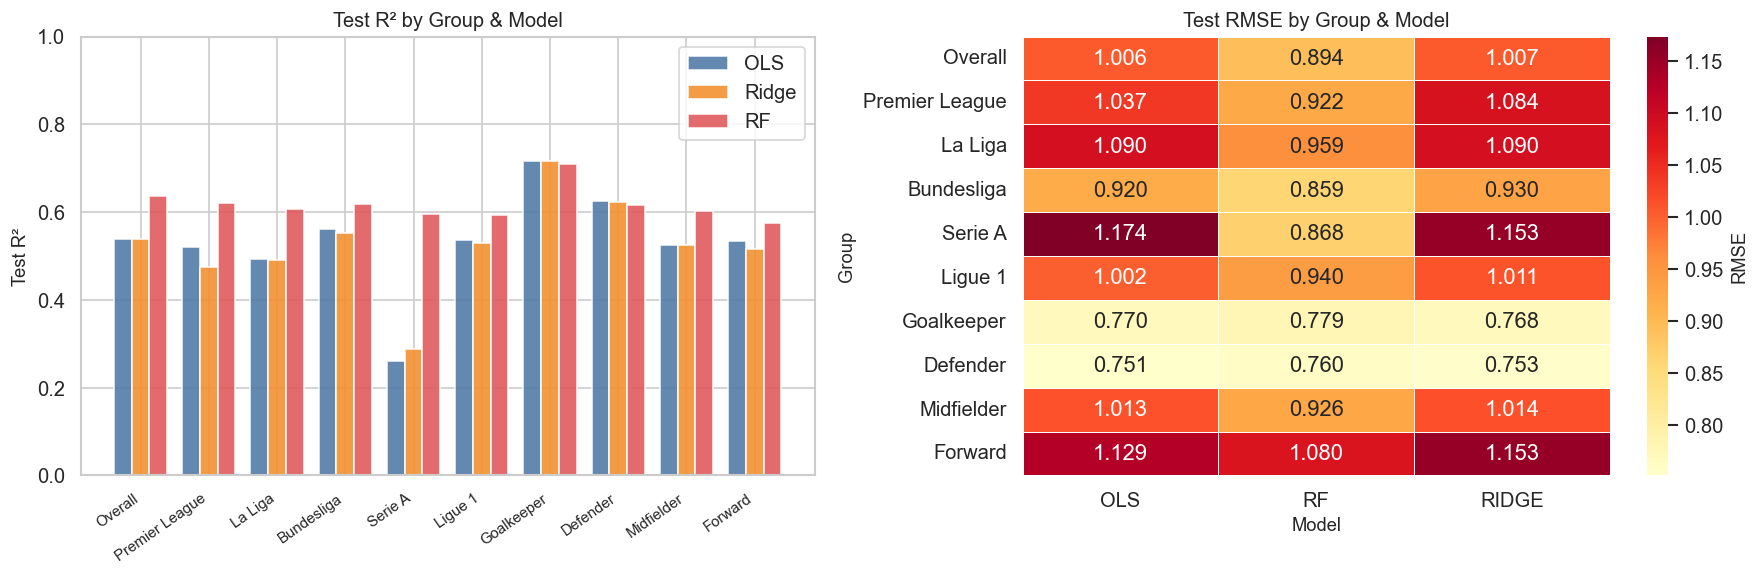

Saved model_performance.png


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

groups = row_order
rf_r2  = [results[g]['rf']['te_r2'] for g in groups]
ols_r2 = [results[g]['ols']['te_r2'] for g in groups]
rg_r2  = [results[g]['ridge']['te_r2'] for g in groups]

x  = np.arange(len(groups)); w = 0.26
axes[0].bar(x - w, ols_r2, w, label='OLS',   color='#4e79a7', alpha=0.88)
axes[0].bar(x,     rg_r2,  w, label='Ridge', color='#f28e2b', alpha=0.88)
axes[0].bar(x + w, rf_r2,  w, label='RF',    color='#e15759', alpha=0.88)
axes[0].set_xticks(x); axes[0].set_xticklabels(groups, rotation=35, ha='right', fontsize=9)
axes[0].set_ylabel('Test R²'); axes[0].set_title('Test R² by Group & Model')
axes[0].legend(); axes[0].set_ylim(0, 1); axes[0].axhline(0, color='k', lw=0.5)

pivot_rmse = perf.pivot(index='Group', columns='Model', values='Test RMSE').reindex(row_order)
sns.heatmap(pivot_rmse, annot=True, fmt='.3f', cmap='YlOrRd',
            ax=axes[1], linewidths=0.5, cbar_kws={'label':'RMSE'})
axes[1].set_title('Test RMSE by Group & Model')
axes[1].tick_params(axis='x', rotation=0)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(f'{OUT_PATH}/model_performance.png', bbox_inches='tight')
plt.show()
print("Saved model_performance.png")

## 7. Actual vs Predicted (Overall Model)

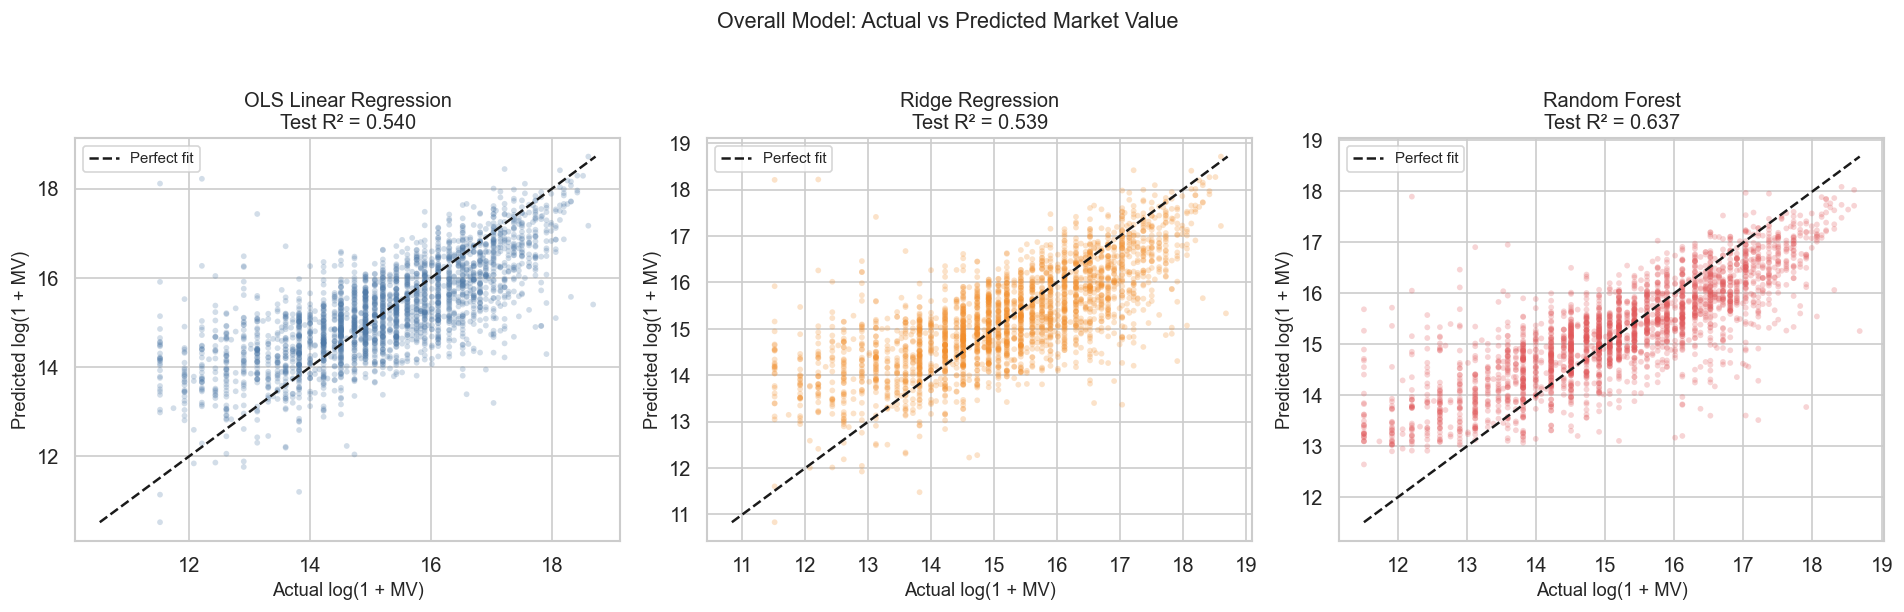

Saved actual_vs_pred_overall.png


In [49]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
model_names = ['OLS Linear Regression', 'Ridge Regression', 'Random Forest']
mkeys       = ['ols', 'ridge', 'rf']
colors      = ['#4e79a7', '#f28e2b', '#e15759']

overall = results['Overall']
for ax, mkey, mname, col in zip(axes, mkeys, model_names, colors):
    yp = overall[mkey]['pred']
    yt = overall[mkey]['y_test']
    te_r2 = overall[mkey]['te_r2']
    ax.scatter(yt, yp, alpha=0.25, s=12, color=col, edgecolors='none')
    mn = min(yt.min(), yp.min()); mx = max(yt.max(), yp.max())
    ax.plot([mn, mx], [mn, mx], 'k--', lw=1.5, label='Perfect fit')
    ax.set_xlabel('Actual log(1 + MV)')
    ax.set_ylabel('Predicted log(1 + MV)')
    ax.set_title(f'{mname}\nTest R² = {te_r2:.3f}')
    ax.legend(fontsize=9)

plt.suptitle('Overall Model: Actual vs Predicted Market Value', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_PATH}/actual_vs_pred_overall.png', bbox_inches='tight')
plt.show()
print("Saved actual_vs_pred_overall.png")

## 8. Overall Model Feature Importance

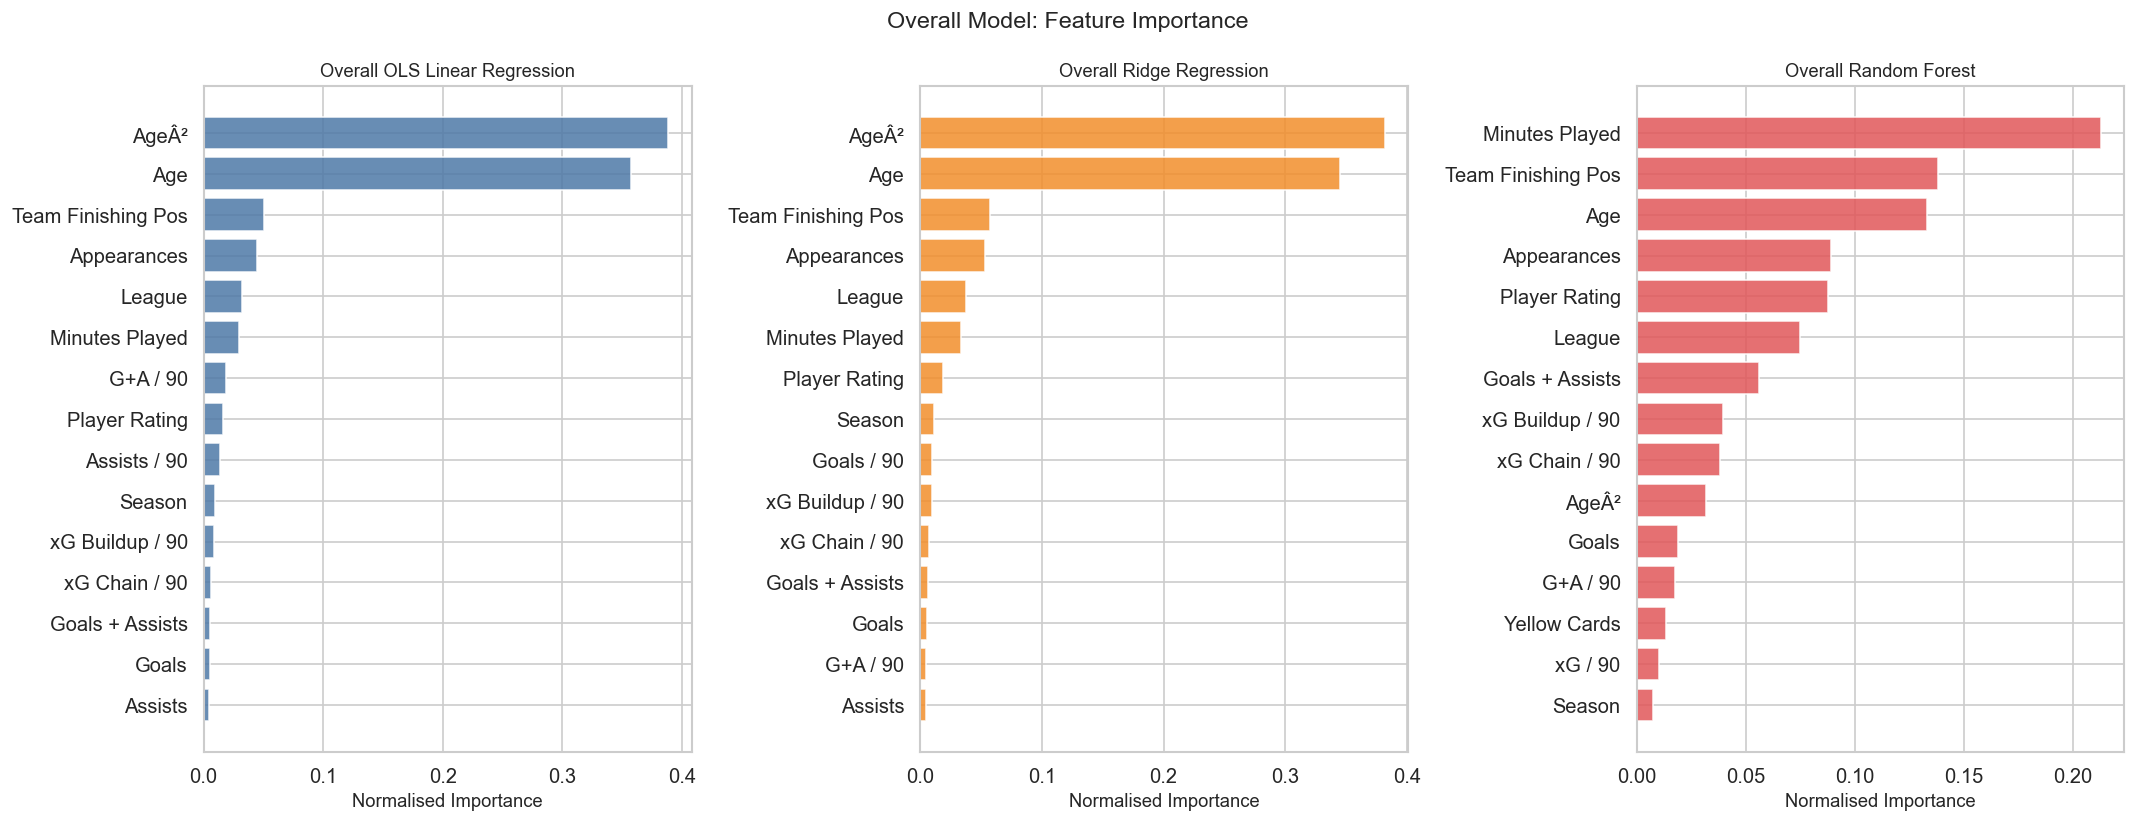

Saved feat_imp_overall.png


In [50]:
def plot_importance(ax, feats, imp, title, color='steelblue', topn=15):
    labels = [lbl(f) for f in feats]
    idx    = np.argsort(imp)[-topn:]
    ax.barh([labels[i] for i in idx], imp[idx], color=color, alpha=0.85, edgecolor='white')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Normalised Importance')

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, mkey, mname, col in zip(axes, mkeys, model_names, colors):
    plot_importance(ax, OVERALL_FEATS, results['Overall'][mkey]['imp'],
                    f'Overall {mname}', color=col)

plt.suptitle('Overall Model: Feature Importance', fontsize=14)
plt.tight_layout()
plt.savefig(f'{OUT_PATH}/feat_imp_overall.png', bbox_inches='tight')
plt.show()
print("Saved feat_imp_overall.png")

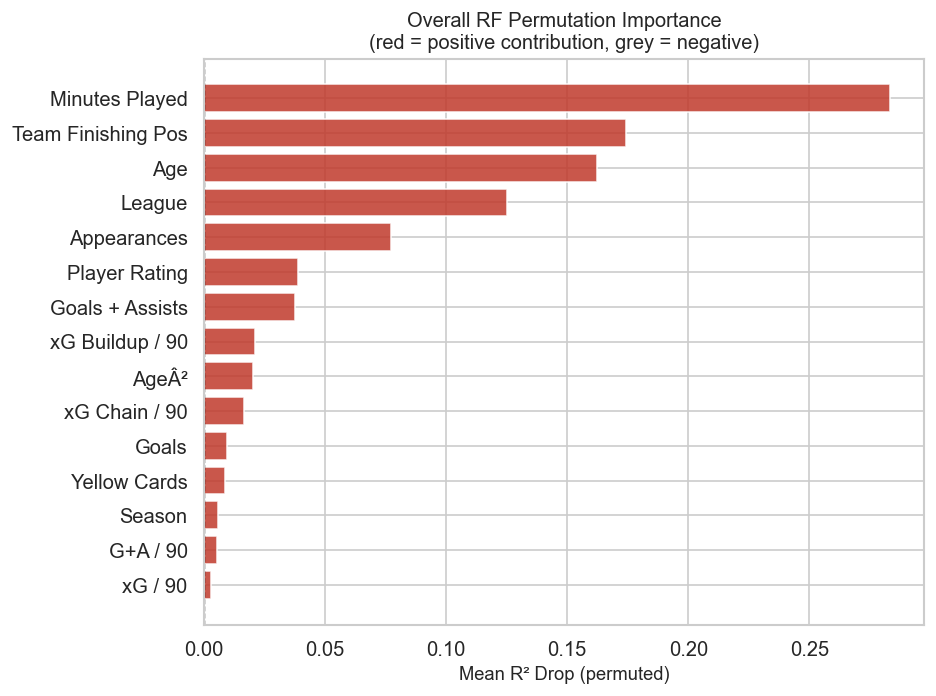

Saved perm_imp_overall.png


In [51]:
fig, ax = plt.subplots(figsize=(8, 6))
perm = results['Overall']['rf']['perm']
idx  = np.argsort(perm)[-15:]
cols = ['#c0392b' if perm[i] > 0 else '#7f8c8d' for i in idx]
ax.barh([lbl(OVERALL_FEATS[i]) for i in idx], perm[idx], color=cols, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', lw=0.8, linestyle='--')
ax.set_xlabel('Mean R² Drop (permuted)')
ax.set_title('Overall RF Permutation Importance\n(red = positive contribution, grey = negative)')
plt.tight_layout()
plt.savefig(f'{OUT_PATH}/perm_imp_overall.png', bbox_inches='tight')
plt.show()
print("Saved perm_imp_overall.png")

## 9. Per-League Analysis

Each of the Big 5 leagues is modelled separately using the same player-performance features, allowing us to examine whether feature importance differs across competitions.


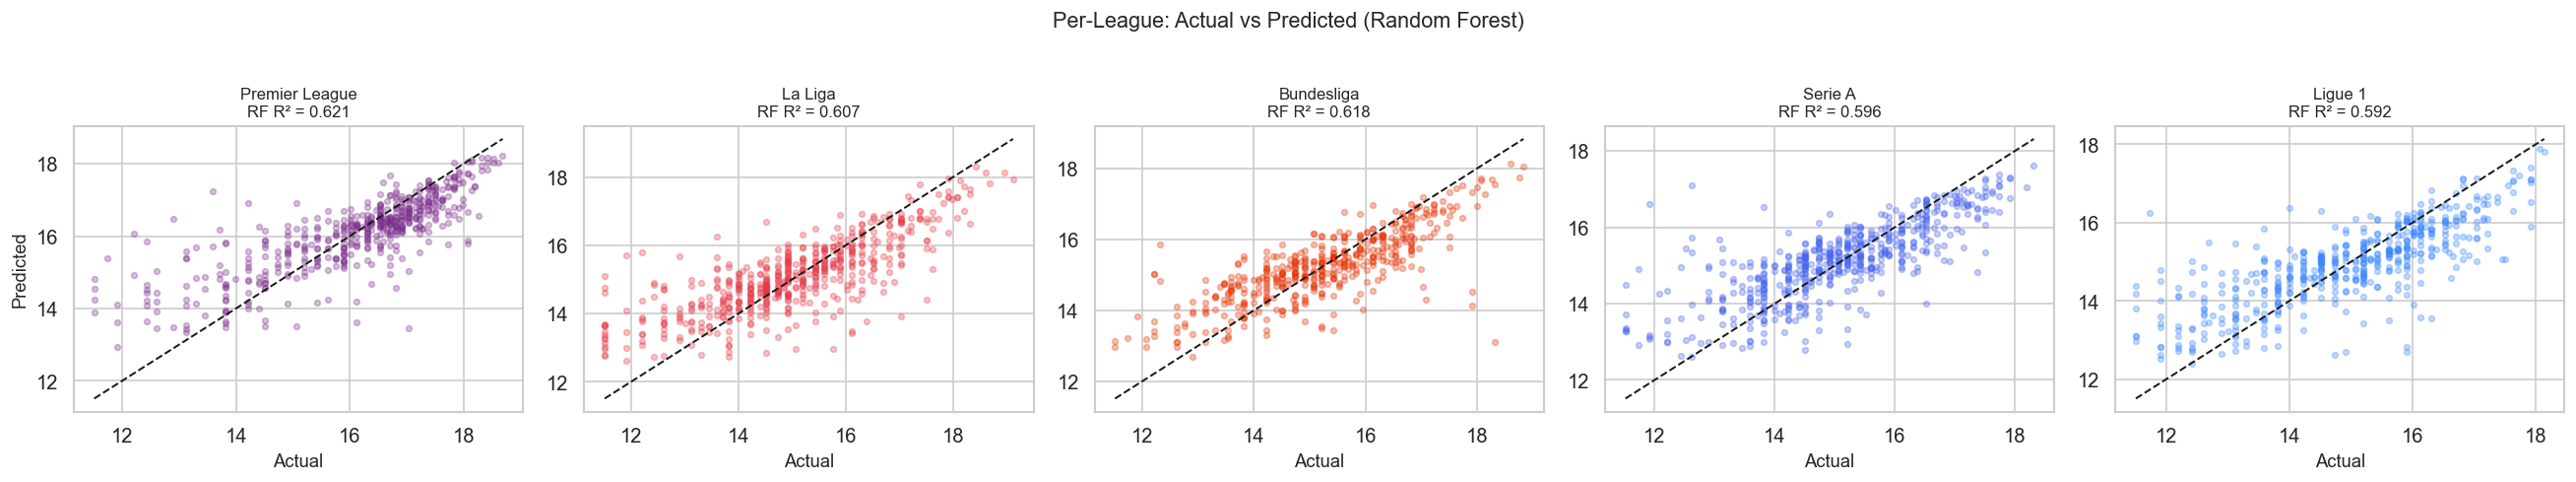

In [52]:
league_list = ['Premier League','La Liga','Bundesliga','Serie A','Ligue 1']
league_colors = {'Premier League':'#7b2d8b','La Liga':'#e63946','Bundesliga':'#e63000','Serie A':'#4361ee','Ligue 1':'#3a86ff'}

fig, axes = plt.subplots(1, 5, figsize=(22, 4), sharey=False)
for ax, lg in zip(axes, league_list):
    res = results[lg]
    yp  = res['rf']['pred']; yt = res['rf']['y_test']
    te  = res['rf']['te_r2']
    ax.scatter(yt, yp, alpha=0.3, s=12, color=league_colors[lg])
    mn = min(yt.min(), yp.min()); mx = max(yt.max(), yp.max())
    ax.plot([mn, mx], [mn, mx], 'k--', lw=1.2)
    ax.set_title(f'{lg}\nRF R² = {te:.3f}', fontsize=10)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted' if lg == 'Premier League' else '')

plt.suptitle('Per-League: Actual vs Predicted (Random Forest)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_PATH}/per_league_actual_vs_pred.png', bbox_inches='tight')
plt.show()

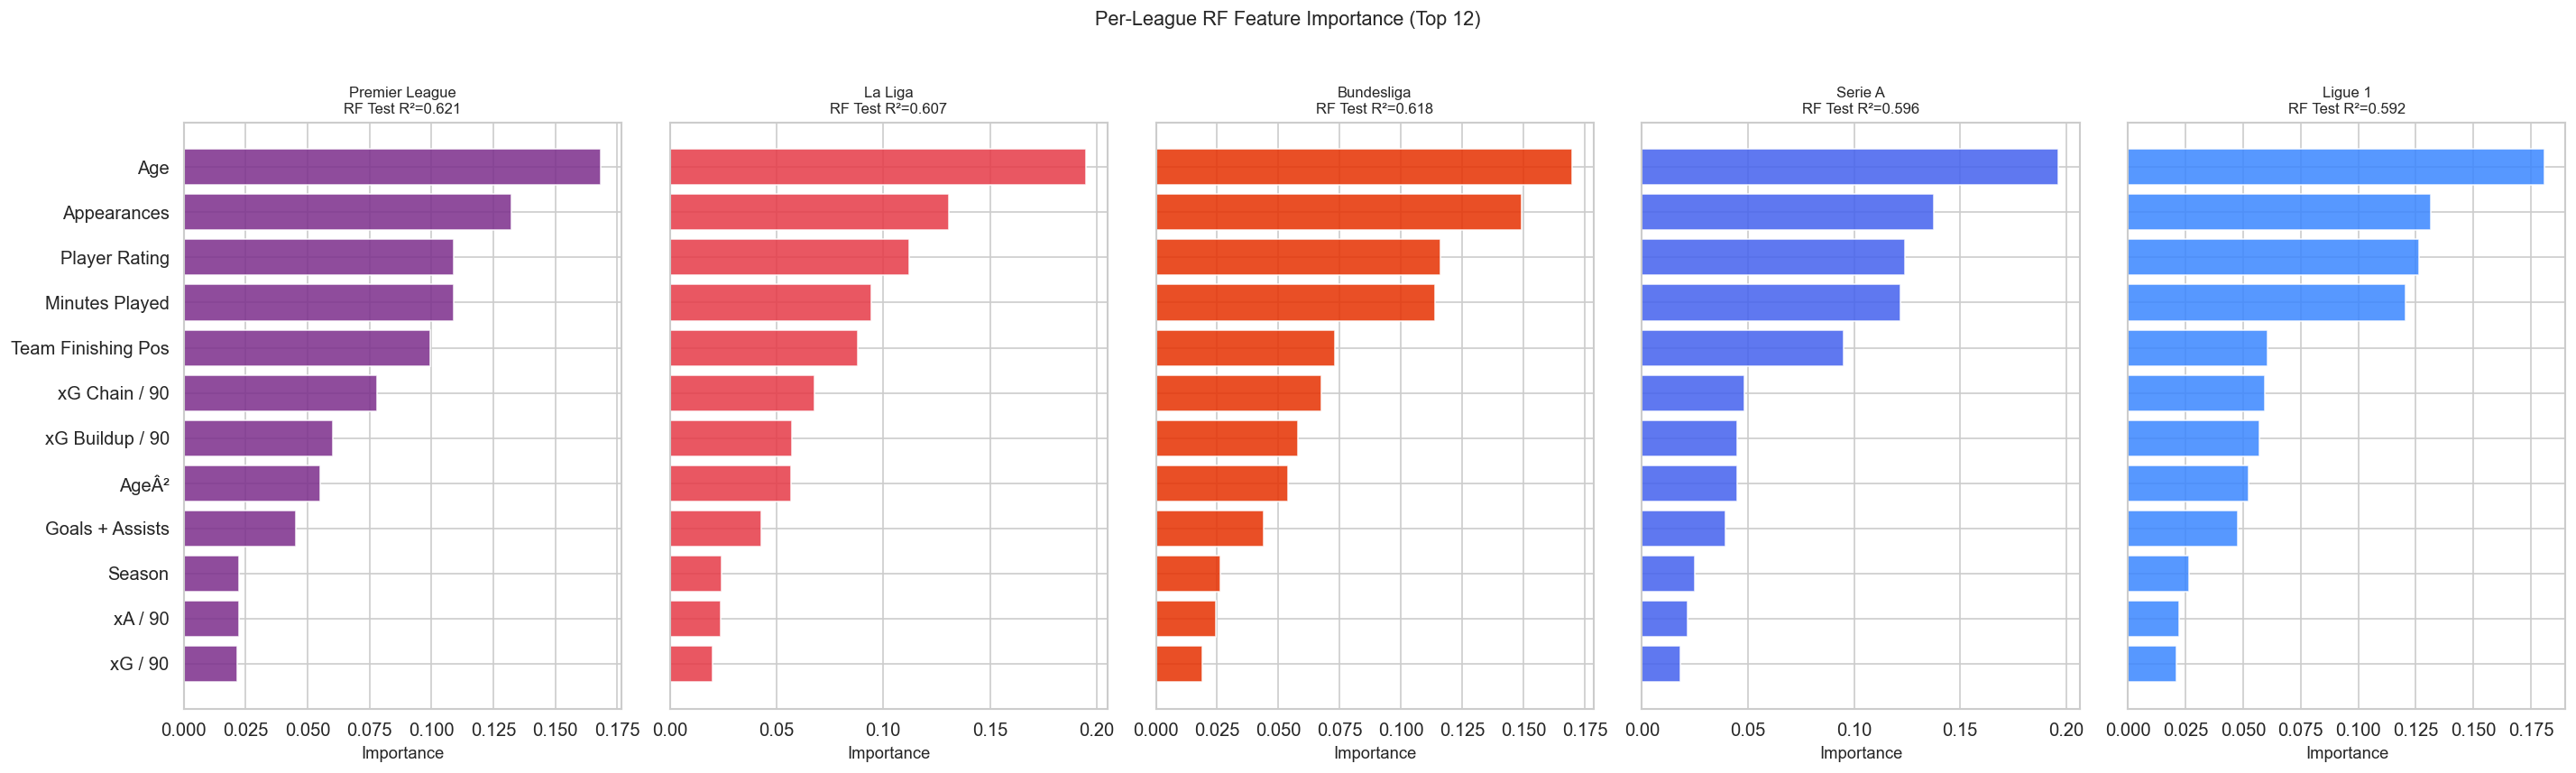

Saved feat_imp_per_league.png


In [53]:
fig, axes = plt.subplots(1, 5, figsize=(24, 7), sharey=False)
for ax, lg in zip(axes, league_list):
    imp  = results[lg]['rf']['imp']
    feats = PER_LEAGUE_FEATS
    labels = [lbl(f) for f in feats]
    idx  = np.argsort(imp)[-12:]
    ax.barh([labels[i] for i in idx], imp[idx],
            color=league_colors[lg], alpha=0.85, edgecolor='white')
    ax.set_title(f'{lg}\nRF Test R²={results[lg]["rf"]["te_r2"]:.3f}', fontsize=10)
    ax.set_xlabel('Importance')
    if lg != 'Premier League': ax.set_yticklabels([])

plt.suptitle('Per-League RF Feature Importance (Top 12)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_PATH}/feat_imp_per_league.png', bbox_inches='tight')
plt.show()
print("Saved feat_imp_per_league.png")

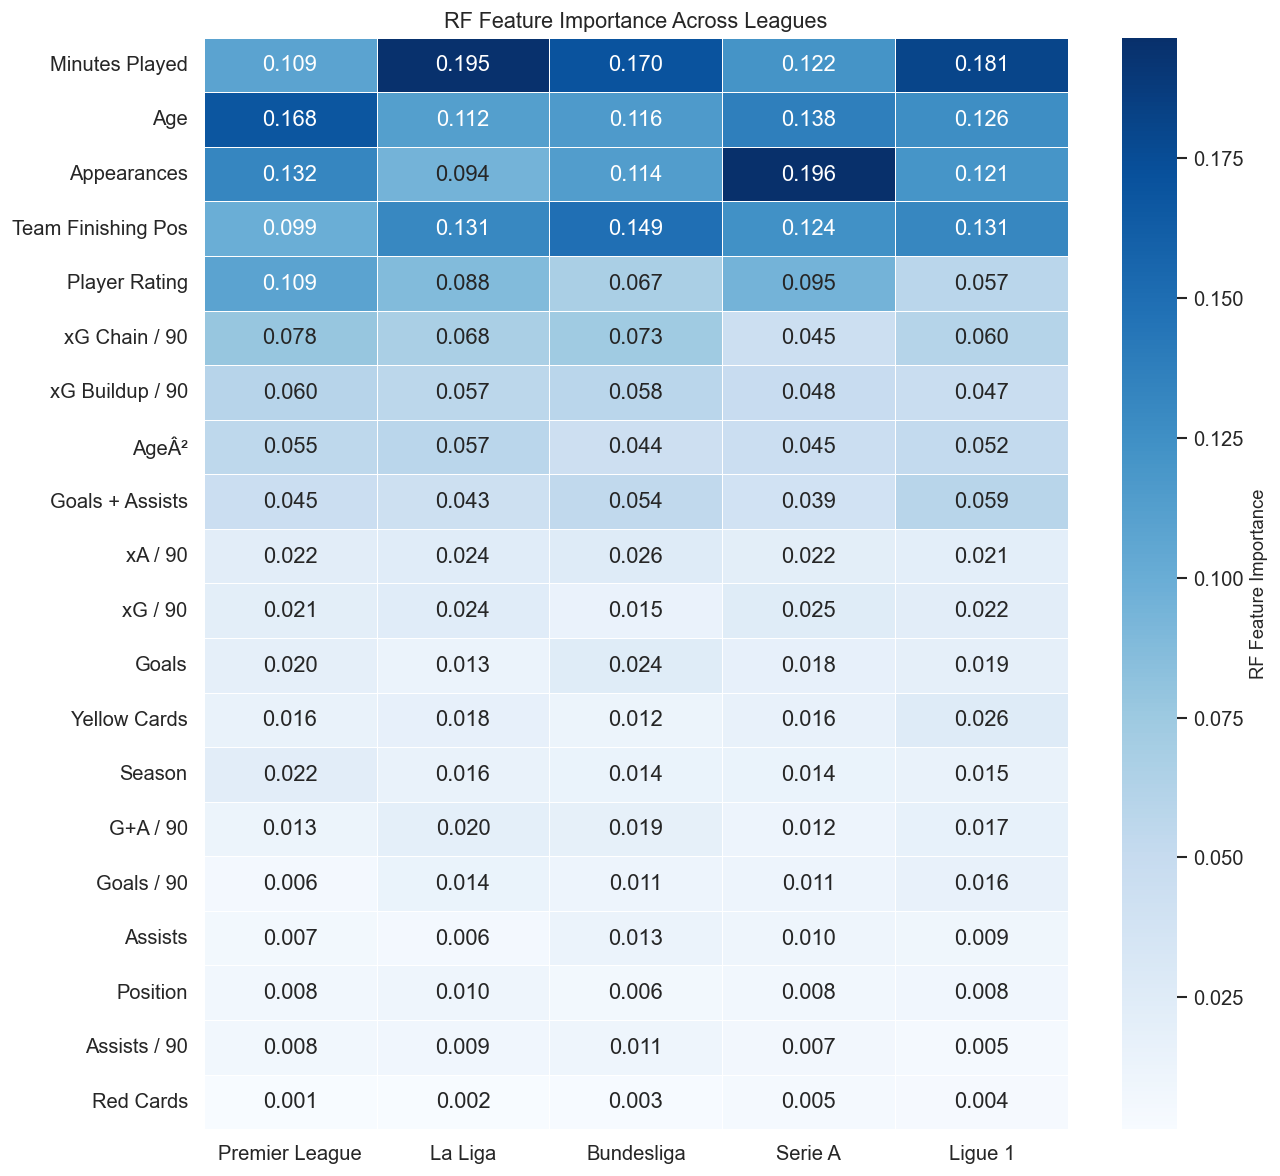

Saved heatmap_leagues.png


In [54]:
league_imp_mat = {}
for lg in league_list:
    imp  = results[lg]['rf']['imp']
    for fi, f in enumerate(PER_LEAGUE_FEATS):
        league_imp_mat.setdefault(f, {})[lg] = imp[fi]

heat_df = pd.DataFrame(league_imp_mat).T.fillna(0)
heat_df.index = [lbl(f) for f in heat_df.index]
heat_df = heat_df.loc[heat_df.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(11, 10))
sns.heatmap(heat_df, annot=True, fmt='.3f', cmap='Blues',
            ax=ax, linewidths=0.4, cbar_kws={'label':'RF Feature Importance'})
ax.set_title('RF Feature Importance Across Leagues', fontsize=13)
ax.set_xlabel(''); ax.set_ylabel('')
plt.tight_layout()
plt.savefig(f'{OUT_PATH}/heatmap_leagues.png', bbox_inches='tight')
plt.show()
print("Saved heatmap_leagues.png")

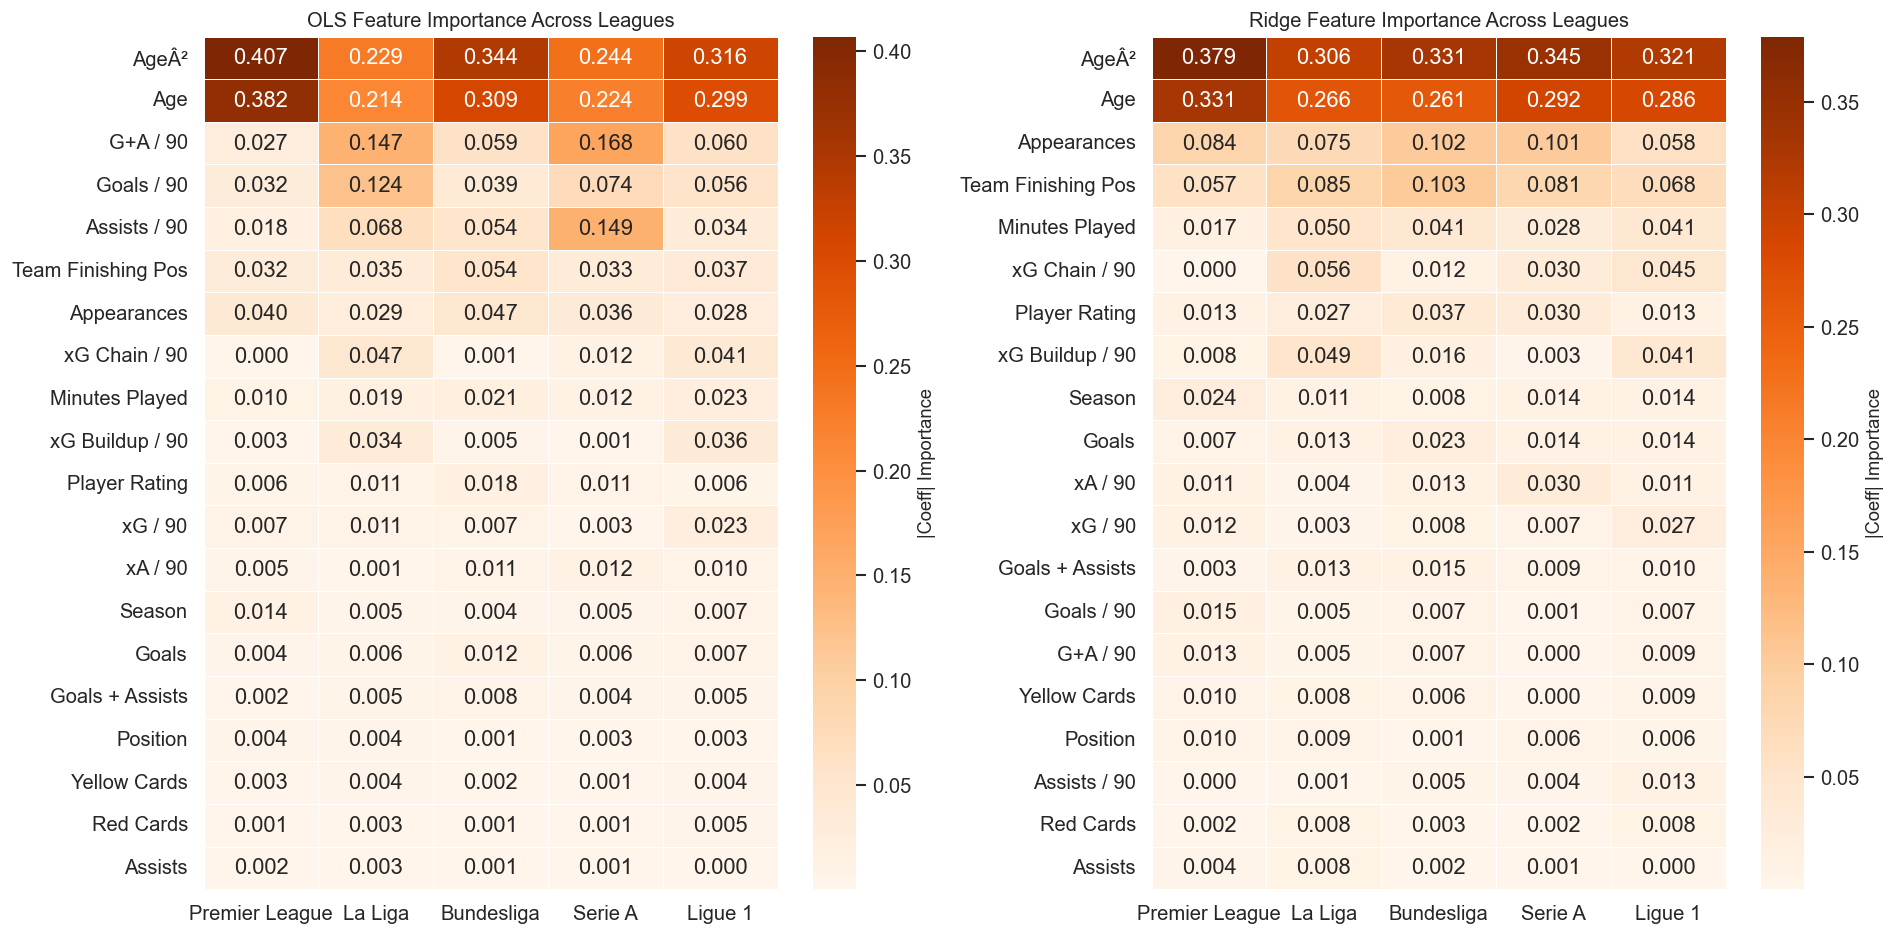

Saved heatmap_leagues_linear.png


In [55]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, mkey, mname in zip(axes, ['ols','ridge'], ['OLS','Ridge']):
    mat = {}
    for lg in league_list:
        for fi, f in enumerate(PER_LEAGUE_FEATS):
            mat.setdefault(f, {})[lg] = results[lg][mkey]['imp'][fi]
    df_heat = pd.DataFrame(mat).T.fillna(0)
    df_heat.index = [lbl(f) for f in df_heat.index]
    df_heat = df_heat.loc[df_heat.mean(axis=1).sort_values(ascending=False).index]
    sns.heatmap(df_heat, annot=True, fmt='.3f', cmap='Oranges',
                ax=ax, linewidths=0.4, cbar_kws={'label':'|Coeff| Importance'})
    ax.set_title(f'{mname} Feature Importance Across Leagues', fontsize=12)

plt.tight_layout()
plt.savefig(f'{OUT_PATH}/heatmap_leagues_linear.png', bbox_inches='tight')
plt.show()
print("Saved heatmap_leagues_linear.png")

## 10. Per-Position Analysis

Position-specific models use tailored feature sets:
- **Goalkeeper**: Clean sheet %, goals conceded/90, win rate
- **Defender**: Defensive proxies (goals conceded/90, clean sheet %), buildup contribution
- **Midfielder**: Full attacking + buildup set
- **Forward**: Full attacking set


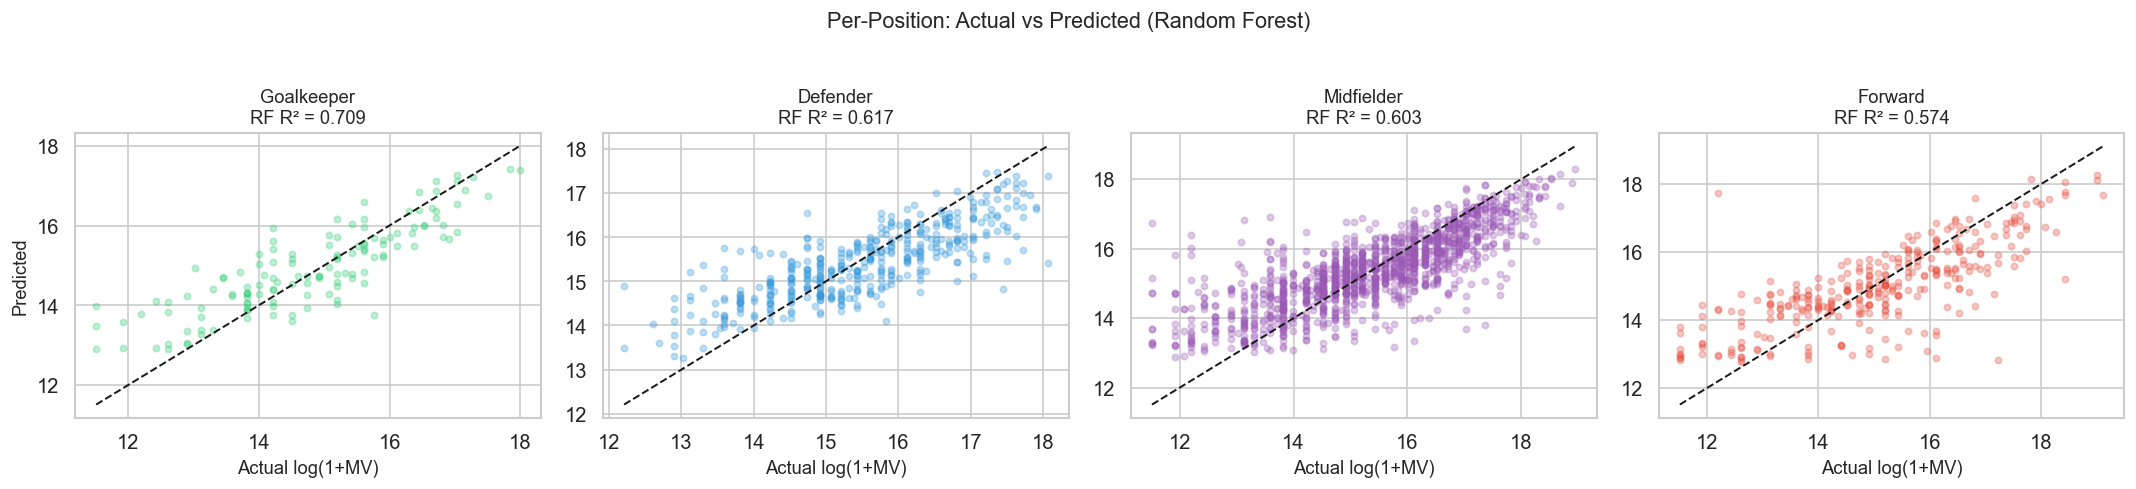

In [56]:
pos_list   = ['Goalkeeper','Defender','Midfielder','Forward']
pos_feats  = {'Goalkeeper': GK_FEATS, 'Defender': DF_FEATS,
              'Midfielder': MF_FEATS,  'Forward':  FW_FEATS}
pos_colors = {'Goalkeeper':'#2ecc71','Defender':'#3498db',
              'Midfielder':'#9b59b6','Forward':'#e74c3c'}

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)
for ax, pos in zip(axes, pos_list):
    res = results[pos]
    yp  = res['rf']['pred']; yt = res['rf']['y_test']; te = res['rf']['te_r2']
    ax.scatter(yt, yp, alpha=0.3, s=14, color=pos_colors[pos])
    mn = min(yt.min(), yp.min()); mx = max(yt.max(), yp.max())
    ax.plot([mn, mx], [mn, mx], 'k--', lw=1.2)
    ax.set_title(f'{pos}\nRF R² = {te:.3f}', fontsize=11)
    ax.set_xlabel('Actual log(1+MV)')
    ax.set_ylabel('Predicted' if pos == 'Goalkeeper' else '')

plt.suptitle('Per-Position: Actual vs Predicted (Random Forest)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_PATH}/per_pos_actual_vs_pred.png', bbox_inches='tight')
plt.show()

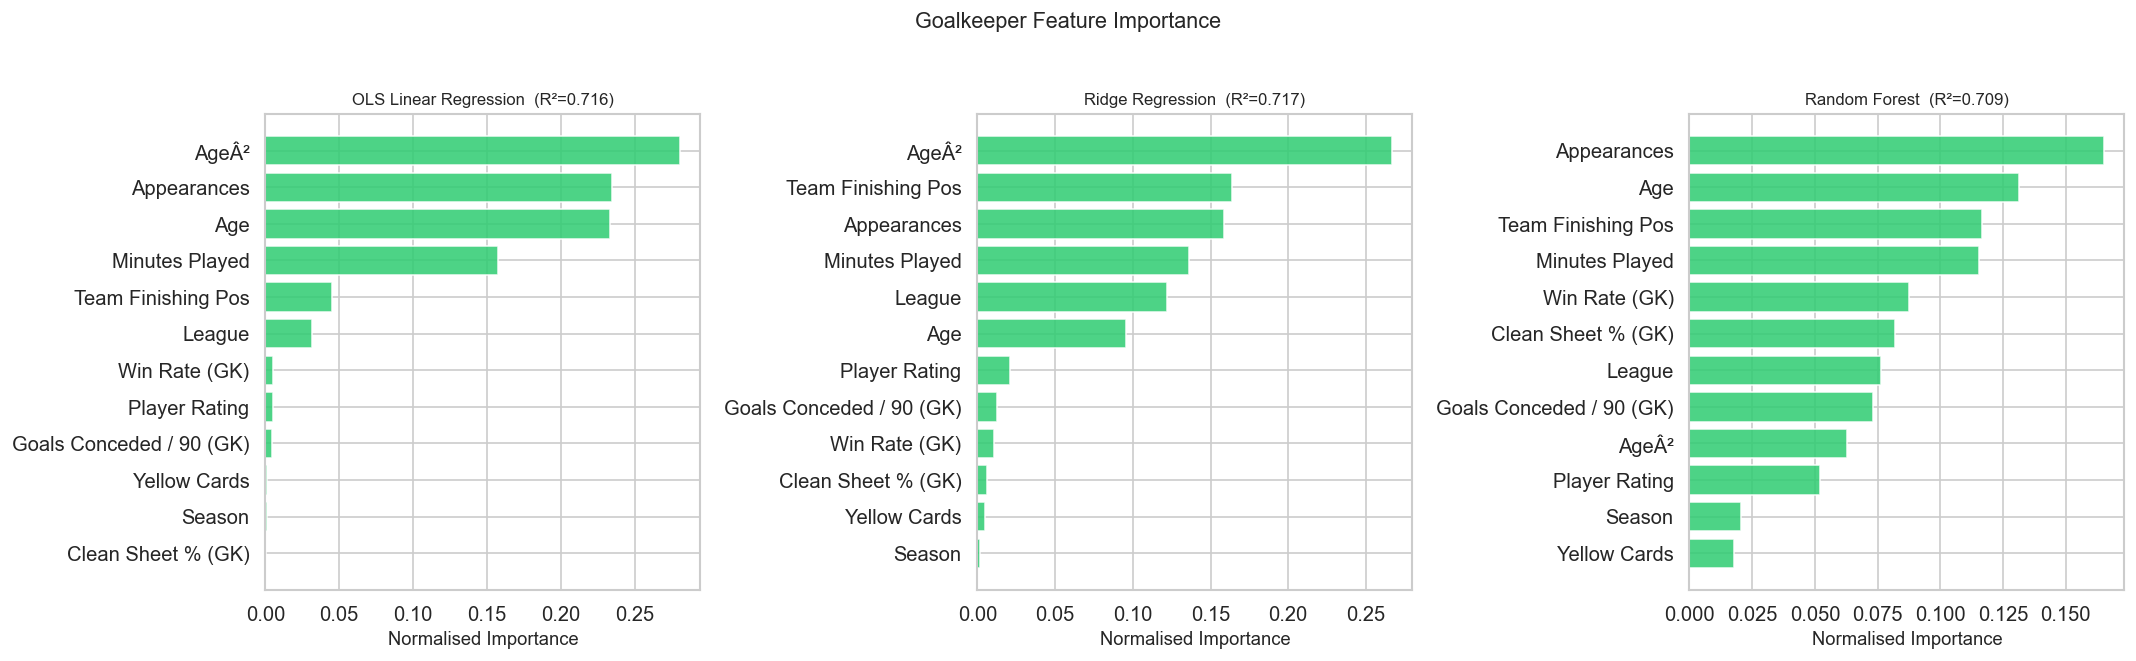

Saved ../outputs/model_results/feat_imp_goalkeeper.png


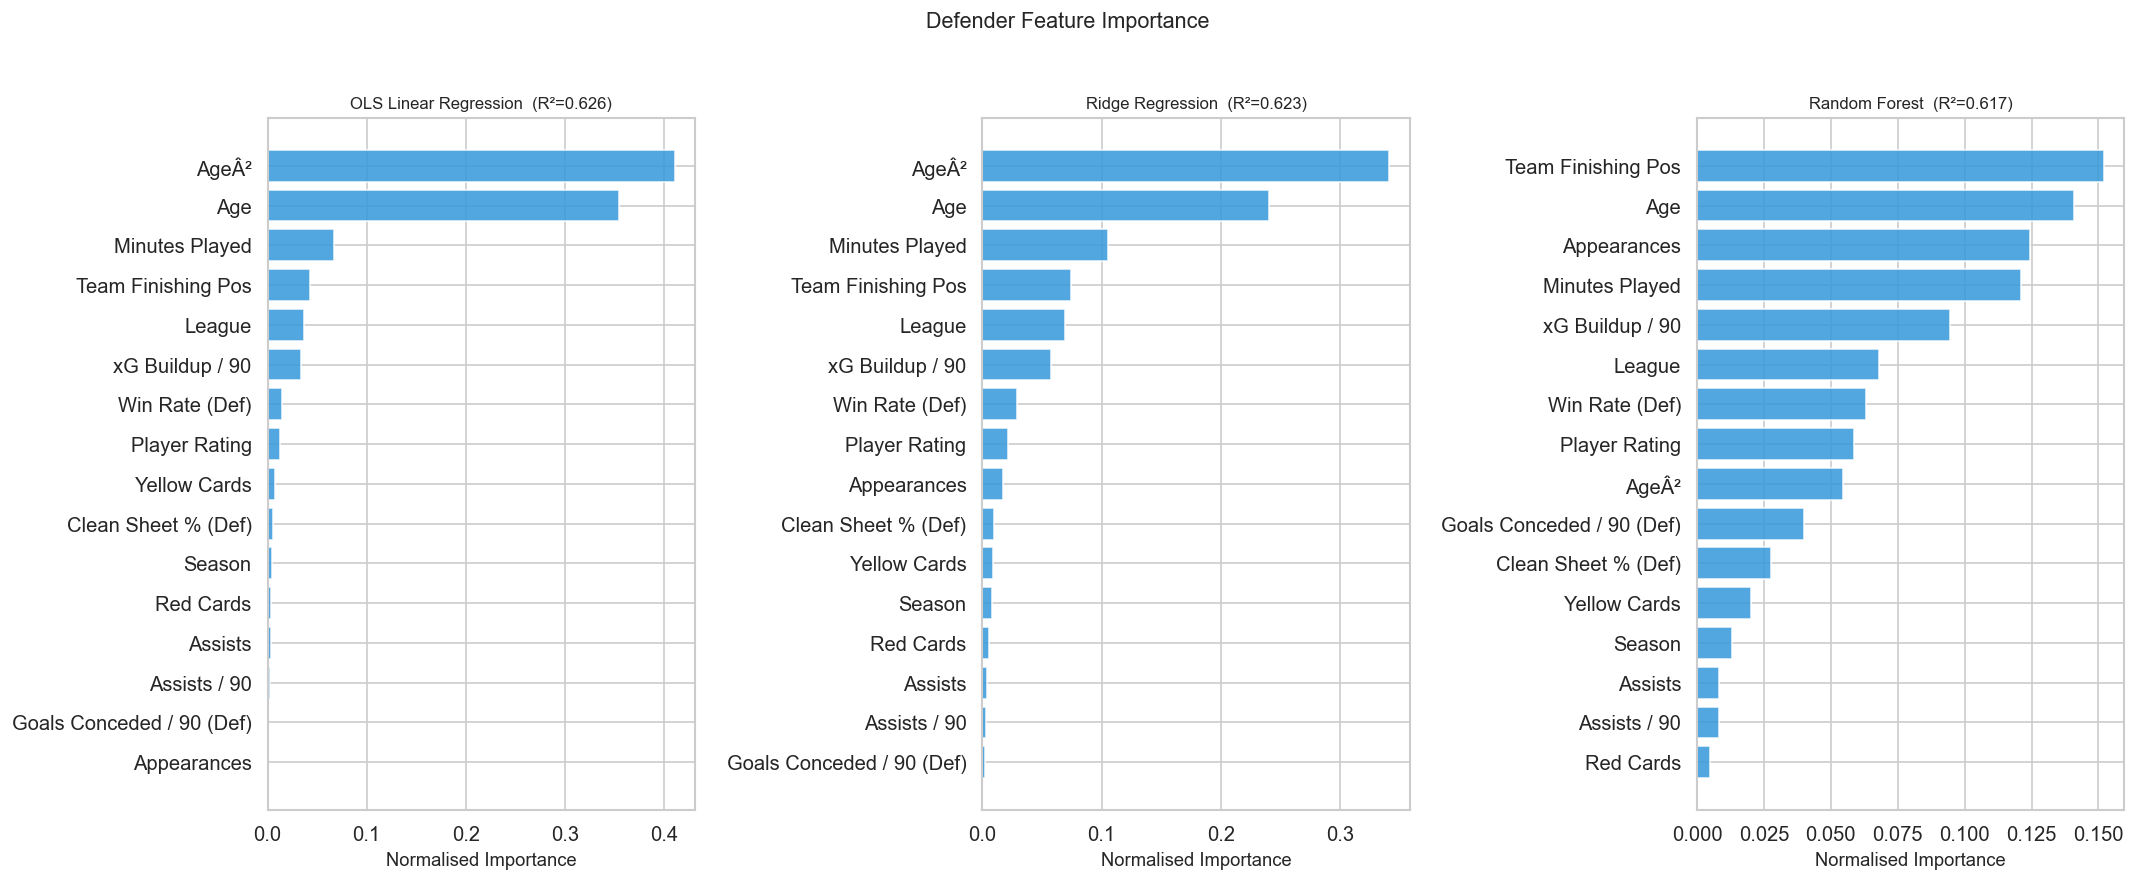

Saved ../outputs/model_results/feat_imp_defender.png


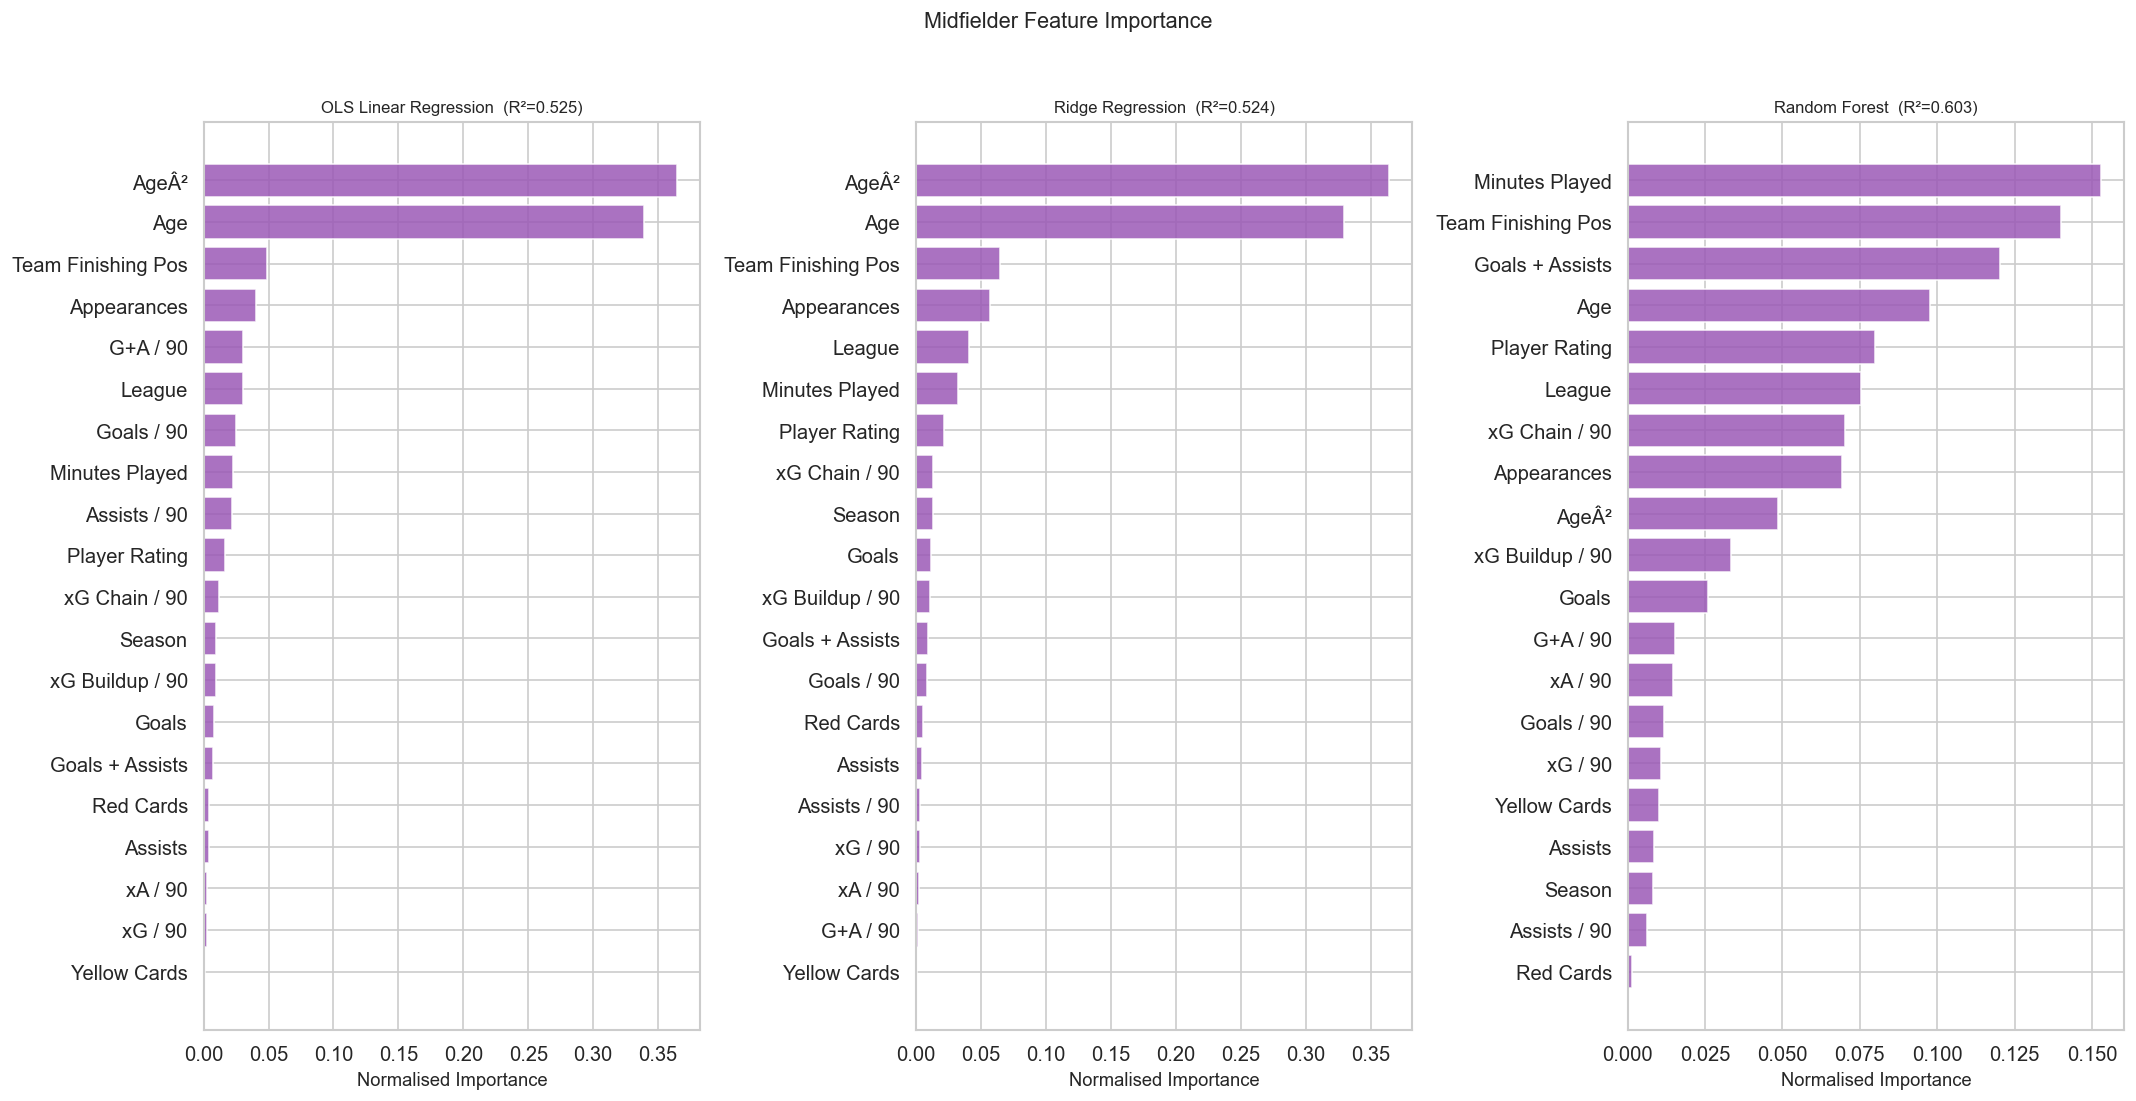

Saved ../outputs/model_results/feat_imp_midfielder.png


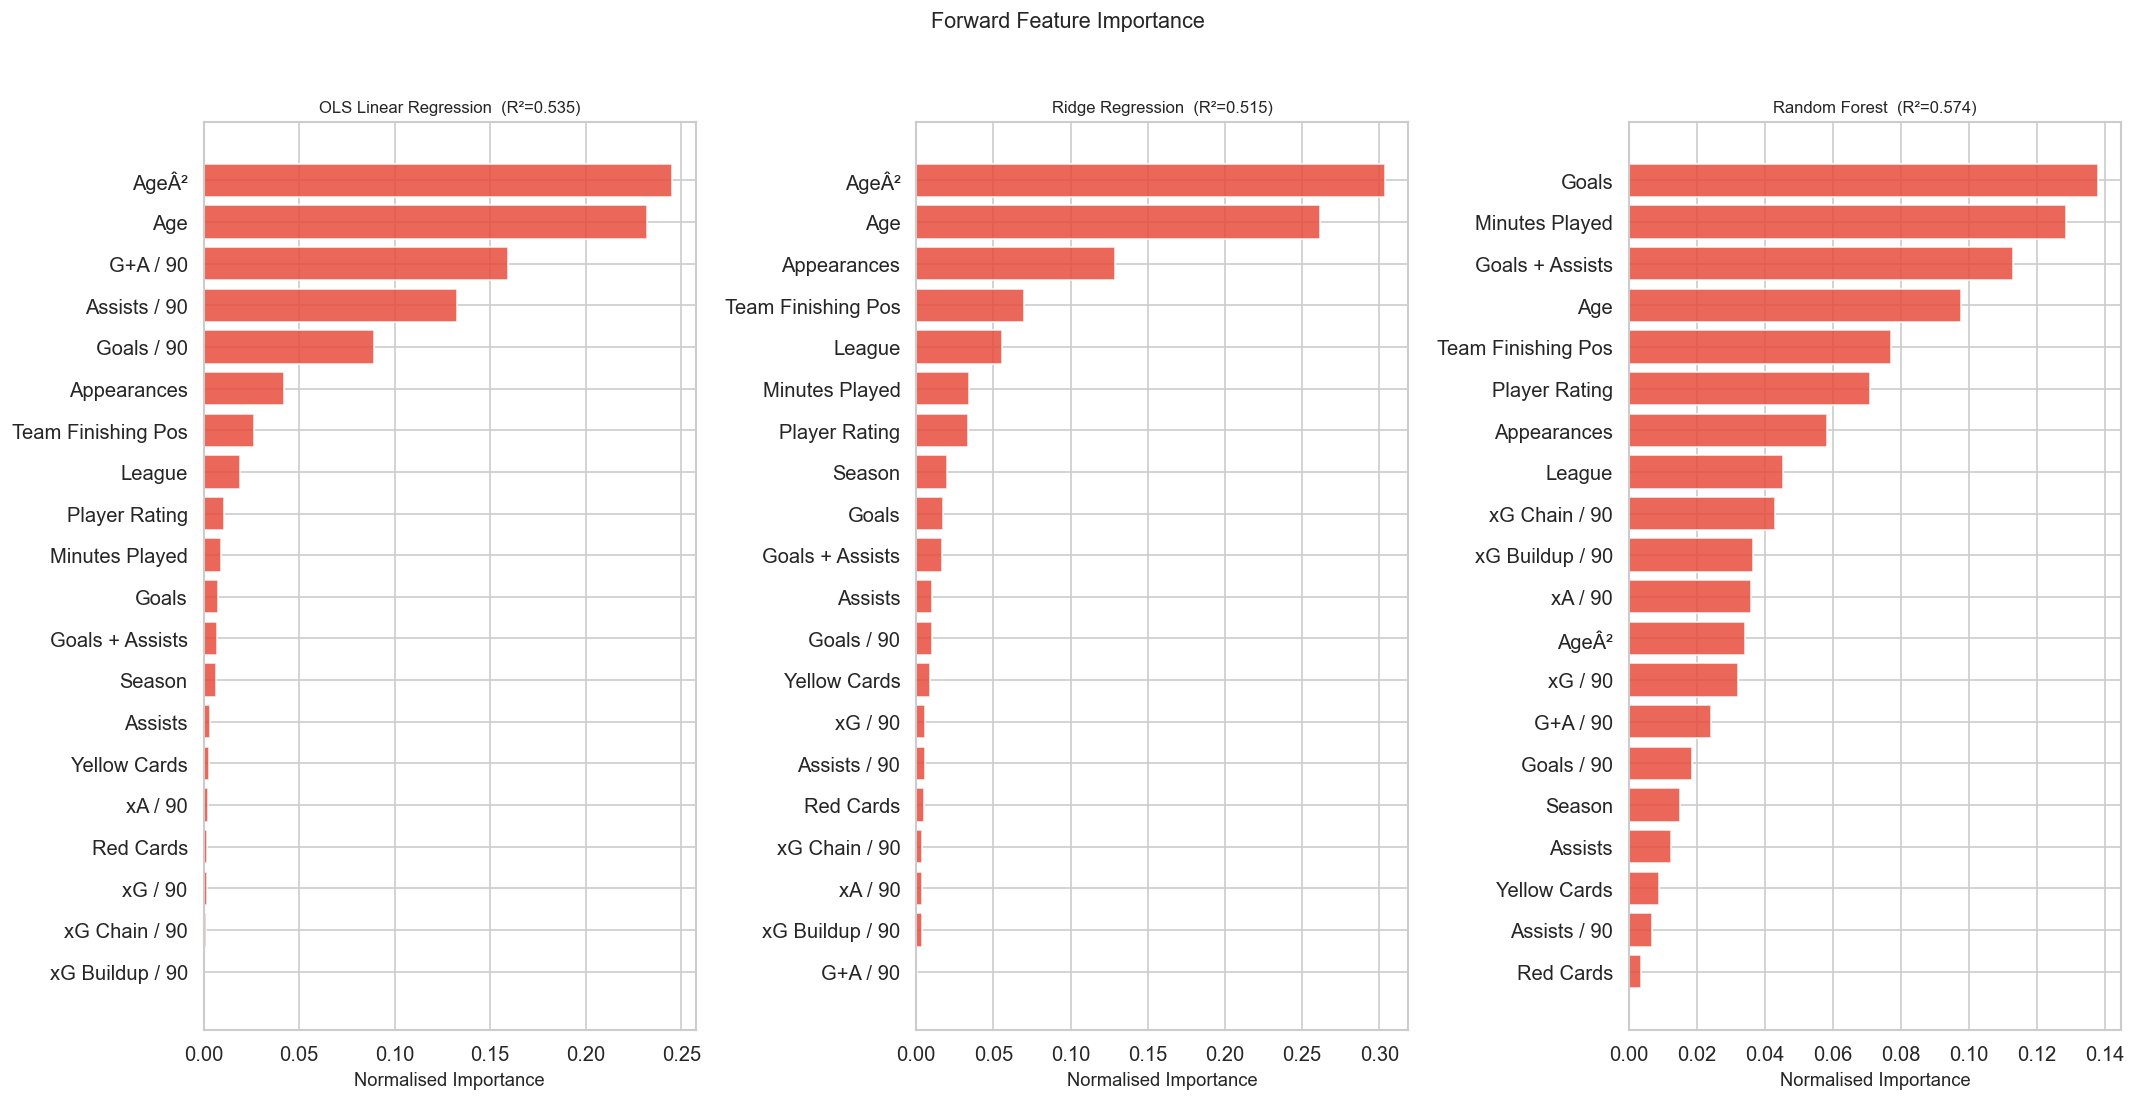

Saved ../outputs/model_results/feat_imp_forward.png


In [57]:
for pos in pos_list:
    feats = pos_feats[pos]
    n_feats = len(feats)
    fig, axes = plt.subplots(1, 3, figsize=(18, max(5, n_feats*0.45)))
    col = pos_colors[pos]
    for ax, mkey, mname in zip(axes, mkeys, model_names):
        imp    = results[pos][mkey]['imp']
        labels = [lbl(f) for f in feats]
        idx    = np.argsort(imp)
        ax.barh([labels[i] for i in idx], imp[idx], color=col, alpha=0.85, edgecolor='white')
        te = results[pos][mkey]['te_r2']
        ax.set_title(f'{mname}  (R²={te:.3f})', fontsize=10)
        ax.set_xlabel('Normalised Importance')
    plt.suptitle(f'{pos} Feature Importance', fontsize=13, y=1.02)
    plt.tight_layout()
    fname = f'{OUT_PATH}/feat_imp_{pos.lower()}.png'
    plt.savefig(fname, bbox_inches='tight')
    plt.show()
    print(f"Saved {fname}")

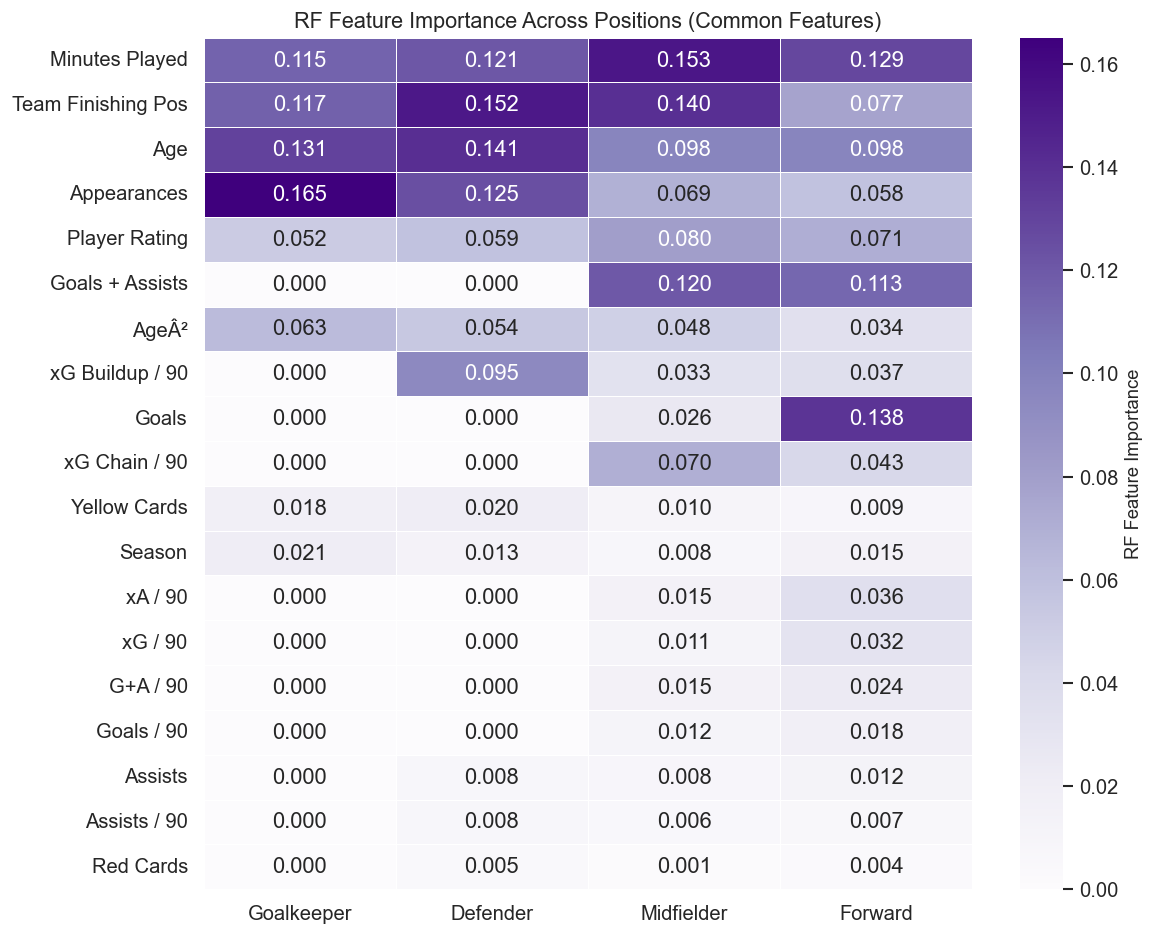

Saved heatmap_positions.png


In [58]:
common_feats = BASE

pos_feat_imp = {}
for pos in pos_list:
    feats = pos_feats[pos]
    imp   = results[pos]['rf']['imp']
    imp_d = {f: imp[i] for i, f in enumerate(feats)}
    for f in common_feats:
        pos_feat_imp.setdefault(f, {})[pos] = imp_d.get(f, 0.0)

heat_pos = pd.DataFrame(pos_feat_imp).T.fillna(0)
heat_pos.index = [lbl(f) for f in heat_pos.index]
heat_pos = heat_pos.loc[heat_pos.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(heat_pos, annot=True, fmt='.3f', cmap='Purples',
            ax=ax, linewidths=0.4, cbar_kws={'label':'RF Feature Importance'})
ax.set_title('RF Feature Importance Across Positions (Common Features)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUT_PATH}/heatmap_positions.png', bbox_inches='tight')
plt.show()
print("Saved heatmap_positions.png")

## 11. Key Findings Summary

In [59]:
print("TOP 5 FEATURES BY GROUP (Random Forest - Normalised Impurity)")

def top5(group_name, feats, imp):
    idx = np.argsort(imp)[::-1][:5]
    return [(lbl(feats[i]), round(imp[i], 4)) for i in idx]

for group in row_order:
    feats = {
        'Overall': OVERALL_FEATS, 'Premier League': PER_LEAGUE_FEATS,
        'La Liga': PER_LEAGUE_FEATS, 'Bundesliga': PER_LEAGUE_FEATS,
        'Serie A': PER_LEAGUE_FEATS, 'Ligue 1': PER_LEAGUE_FEATS,
        'Goalkeeper': GK_FEATS, 'Defender': DF_FEATS,
        'Midfielder': MF_FEATS, 'Forward': FW_FEATS,
    }[group]
    imp = results[group]['rf']['imp']
    top = top5(group, feats, imp)
    print(f"\n{group}:")
    for rank, (feat, val) in enumerate(top, 1):
        print(f"  {rank}. {feat:<30s}  {val:.4f}")


TOP 5 FEATURES BY GROUP (Random Forest - Normalised Impurity)

Overall:
  1. Minutes Played                  0.2131
  2. Team Finishing Pos              0.1380
  3. Age                             0.1333
  4. Appearances                     0.0893
  5. Player Rating                   0.0879

Premier League:
  1. Age                             0.1681
  2. Appearances                     0.1322
  3. Player Rating                   0.1088
  4. Minutes Played                  0.1088
  5. Team Finishing Pos              0.0995

La Liga:
  1. Minutes Played                  0.1951
  2. Team Finishing Pos              0.1307
  3. Age                             0.1123
  4. Appearances                     0.0945
  5. Player Rating                   0.0882

Bundesliga:
  1. Minutes Played                  0.1699
  2. Team Finishing Pos              0.1490
  3. Age                             0.1159
  4. Appearances                     0.1139
  5. xG Chain / 90                   0.0732

Serie A

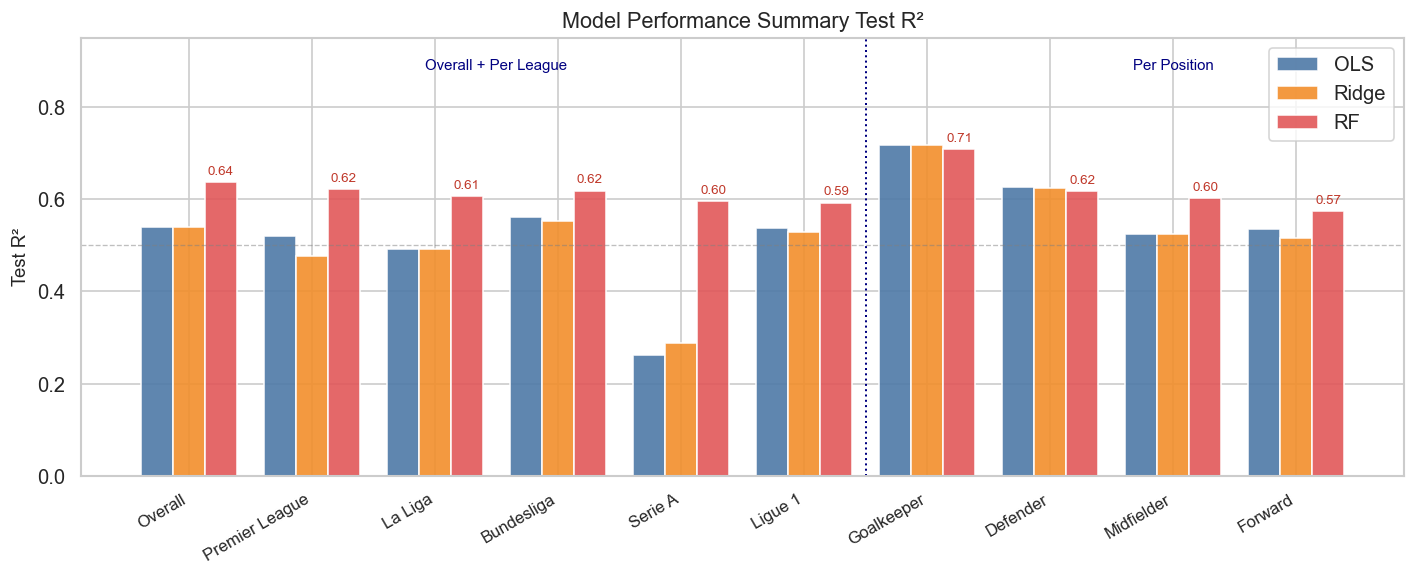


All visualisations saved to: ../outputs/model_results


In [60]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(row_order)); w = 0.26
ols_te  = [results[g]['ols']['te_r2']   for g in row_order]
rg_te   = [results[g]['ridge']['te_r2'] for g in row_order]
rf_te   = [results[g]['rf']['te_r2']    for g in row_order]

b1 = ax.bar(x - w, ols_te, w, label='OLS',   color='#4e79a7', alpha=0.9)
b2 = ax.bar(x,     rg_te,  w, label='Ridge', color='#f28e2b', alpha=0.9)
b3 = ax.bar(x + w, rf_te,  w, label='RF',    color='#e15759', alpha=0.9)

for rect, val in zip(b3, rf_te):
    ax.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.01,
            f'{val:.2f}', ha='center', va='bottom', fontsize=8, color='#c0392b')

ax.set_xticks(x); ax.set_xticklabels(row_order, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Test R²'); ax.set_title('Model Performance Summary Test R²', fontsize=13)
ax.legend(); ax.set_ylim(0, 0.95)
ax.axhline(0.5, color='grey', lw=0.8, linestyle='--', alpha=0.5)

ax.axvline(5.5, color='navy', lw=1.2, linestyle=':')
ax.text(2.5, 0.88, 'Overall + Per League', ha='center', fontsize=9, color='navy')
ax.text(8.0, 0.88, 'Per Position',         ha='center', fontsize=9, color='navy')

plt.tight_layout()
plt.savefig(f'{OUT_PATH}/final_summary.png', bbox_inches='tight')
plt.show()
print("\nAll visualisations saved to:", OUT_PATH)

## 12. Year-on-Year Analysis

For each league, models are re-fitted separately on each season so we can track:
- How **market values** have inflated or deflated year-on-year
- How **feature importance** shifts across seasons within each league
- Whether **model predictive power** is stable or varies
- The **direction** of each feature's effect (OLS signed coefficients) over time


In [61]:
SEASONS = ['2020-2021','2021-2022','2022-2023','2023-2024','2024-2025']
SEASON_LABELS = ['20/21','21/22','22/23','23/24','24/25']
PER_SEASON_FEATS = BASE + ['pos_enc']

def run_season_model(Xtr, Xte, ytr, yte, Xtr_s, Xte_s, feats):
    lr_c   = ols_fit(Xtr_s, ytr)
    lr_imp = np.abs(lr_c[1:]); lr_imp /= (lr_imp.sum() + 1e-12)
    rf_m   = RandomForest(n_estimators=40, max_depth=6, max_features=0.6,
                          min_samples=12, subsample=0.85, seed=42)
    rf_m.fit(Xtr, ytr)
    return {
        'ols_r2':   r2(yte, linear_predict(Xte_s, lr_c)),
        'rf_r2':    r2(yte, rf_m.predict(Xte)),
        'ols_imp':  lr_imp,
        'rf_imp':   rf_m.feature_importances_,
        'ols_coef': lr_c[1:],
    }

print('Fitting 25 per-season models (5 leagues x 5 seasons)...')
yoy = {}
for lg_name, lg_comp in LEAGUES.items():
    yoy[lg_name] = {}
    for season in SEASONS:
        sub = df[(df['league_comp'] == lg_comp) & (df['season'] == season)]
        s   = prep_split(sub, PER_SEASON_FEATS)
        if s:
            yoy[lg_name][season] = run_season_model(*s, PER_SEASON_FEATS)
    print(f'  {lg_name}: {len(yoy[lg_name])}/5 seasons fit')
print('Done.')


Fitting 25 per-season models (5 leagues x 5 seasons)...
  Premier League: 5/5 seasons fit
  La Liga: 5/5 seasons fit
  Bundesliga: 5/5 seasons fit
  Serie A: 5/5 seasons fit
  Ligue 1: 5/5 seasons fit
Done.


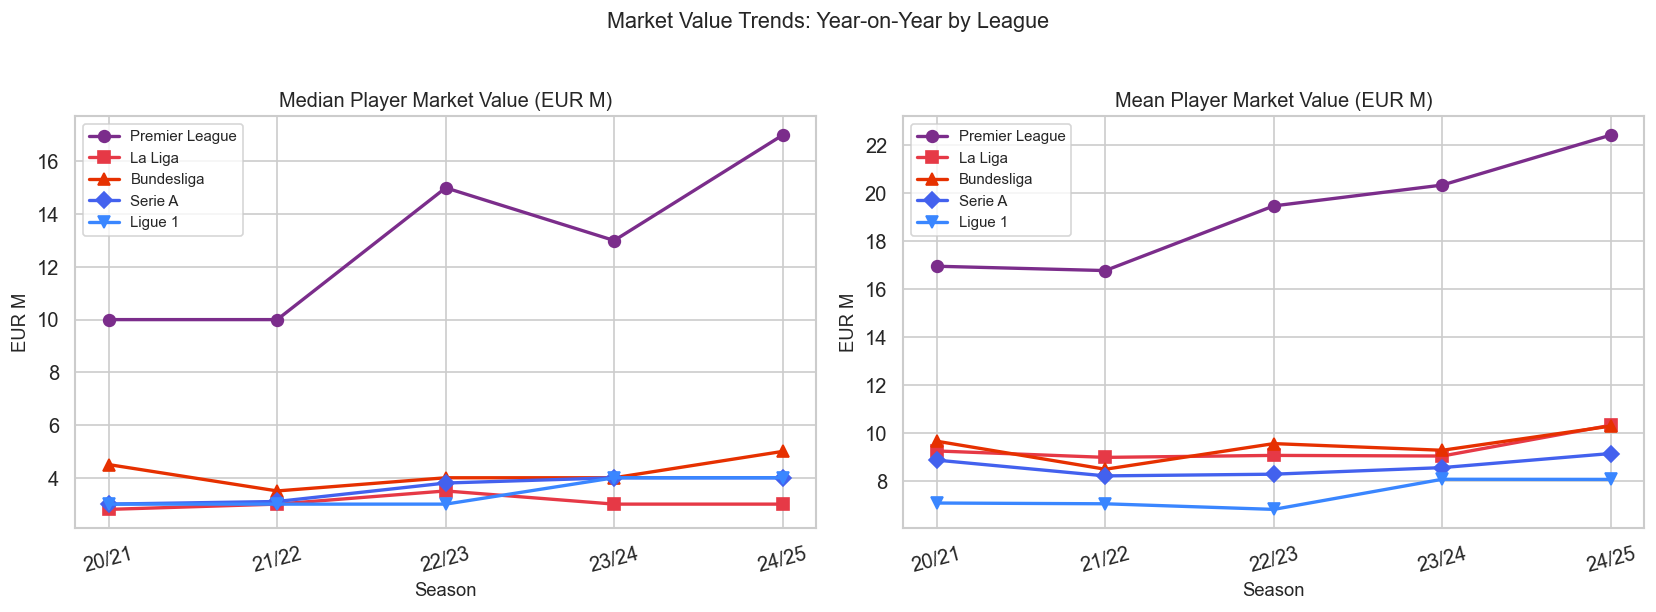

In [62]:
lc = {'Premier League':'#7b2d8b','La Liga':'#e63946','Bundesliga':'#e63000',
      'Serie A':'#4361ee','Ligue 1':'#3a86ff'}
lm = {'Premier League':'o','La Liga':'s','Bundesliga':'^','Serie A':'D','Ligue 1':'v'}
lg_label_map = {'eng Premier League':'Premier League','es La Liga':'La Liga',
                'de Bundesliga':'Bundesliga','it Serie A':'Serie A','fr Ligue 1':'Ligue 1'}

mv_stats = (df.groupby(['league_comp','season'])['market_value_end']
              .agg(['median','mean']).reset_index())
mv_stats.columns = ['league_comp','season','median_mv','mean_mv']
mv_stats['median_mv_M'] = mv_stats['median_mv'] / 1e6
mv_stats['mean_mv_M']   = mv_stats['mean_mv']   / 1e6
mv_stats['league'] = mv_stats['league_comp'].map(lg_label_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for lg in LEAGUES:
    sub   = mv_stats[mv_stats['league']==lg].sort_values('season')
    slbls = [SEASON_LABELS[SEASONS.index(s)] for s in sub['season']]
    axes[0].plot(slbls, sub['median_mv_M'], marker=lm[lg], color=lc[lg], linewidth=2, label=lg, markersize=7)
    axes[1].plot(slbls, sub['mean_mv_M'],   marker=lm[lg], color=lc[lg], linewidth=2, label=lg, markersize=7)
for ax, title in zip(axes, ['Median Player Market Value (EUR M)', 'Mean Player Market Value (EUR M)']):
    ax.set_xlabel('Season'); ax.set_ylabel('EUR M')
    ax.set_title(title); ax.legend(fontsize=9); ax.tick_params(axis='x', rotation=15)
plt.suptitle('Market Value Trends: Year-on-Year by League', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_PATH}/yoy_mv_trends.png', bbox_inches='tight')
plt.show()


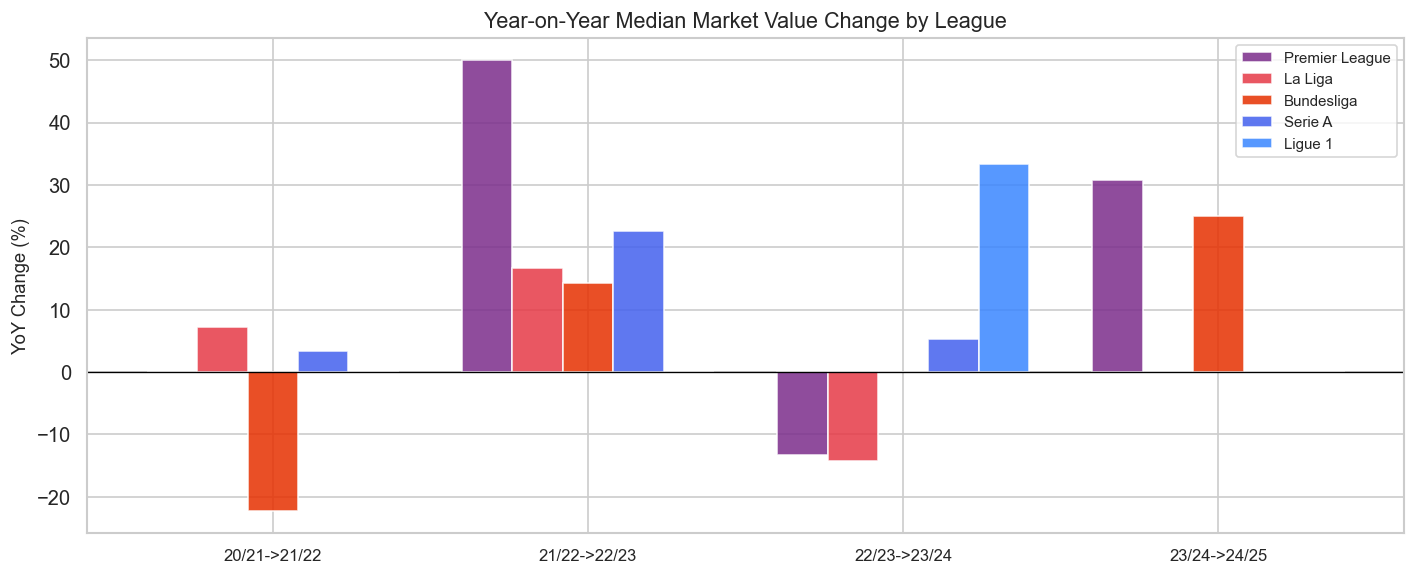

In [63]:
mv_pct = (df.groupby(['league_comp','season'])['market_value_end']
            .median().reset_index().rename(columns={'market_value_end':'med_mv'}))
mv_pct['league'] = mv_pct['league_comp'].map(lg_label_map)

fig, ax = plt.subplots(figsize=(12, 5))
width = 0.16; x = np.arange(len(SEASONS)-1)
x_labels = [f'{SEASON_LABELS[i]}->{SEASON_LABELS[i+1]}' for i in range(len(SEASONS)-1)]
for i, lg in enumerate(LEAGUES):
    sub  = mv_pct[mv_pct['league']==lg].sort_values('season')['med_mv'].values
    pcts = [(sub[j+1]-sub[j])/sub[j]*100 for j in range(len(sub)-1)]
    ax.bar(x + i*width - 2*width, pcts, width=width, color=lc[lg], alpha=0.85, label=lg, edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(x_labels, fontsize=10)
ax.set_ylabel('YoY Change (%)'); ax.set_title('Year-on-Year Median Market Value Change by League', fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUT_PATH}/yoy_mv_pct_change.png', bbox_inches='tight')
plt.show()


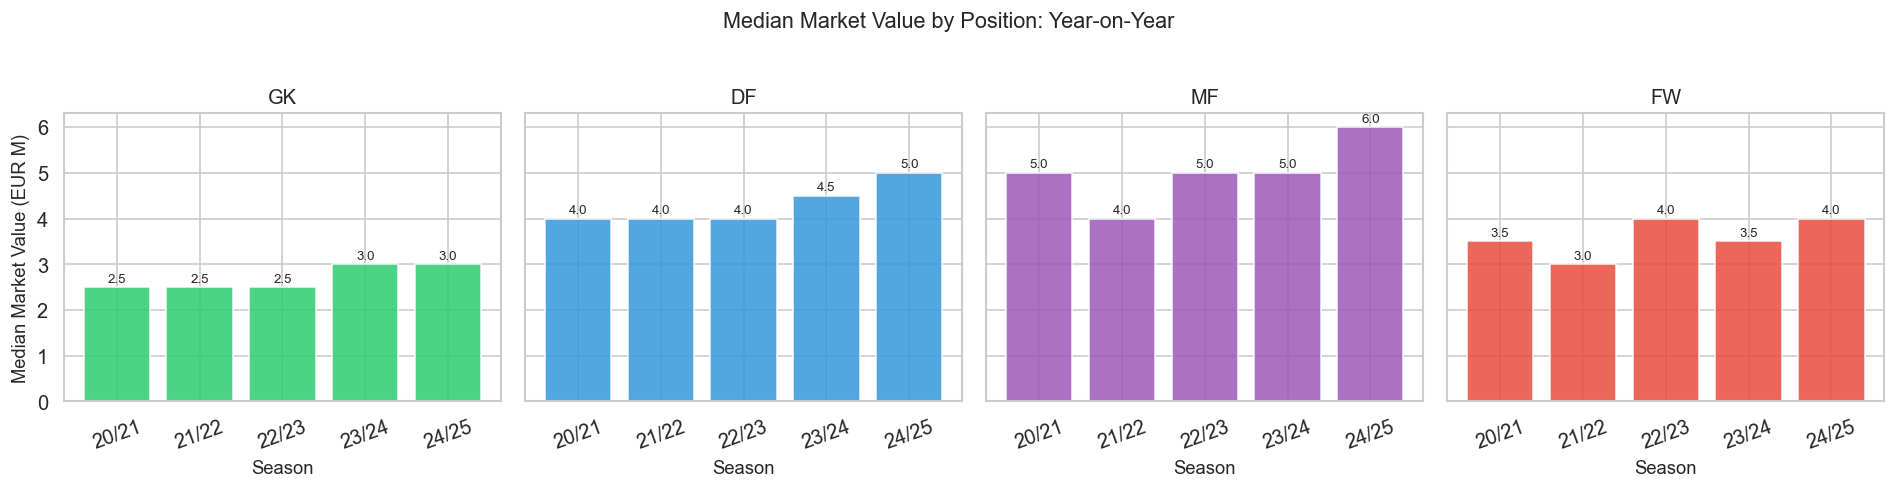

In [64]:
pos_labels_map = {0:'GK', 1:'DF', 2:'MF', 3:'FW'}
pos_colors_p = {'GK':'#2ecc71','DF':'#3498db','MF':'#9b59b6','FW':'#e74c3c'}
df['pos_label'] = df['pos_enc'].map(pos_labels_map)
mv_pos = (df.groupby(['season','pos_label'])['market_value_end'].median().reset_index())
mv_pos['mv_M'] = mv_pos['market_value_end'] / 1e6

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, pos in zip(axes, ['GK','DF','MF','FW']):
    sub   = mv_pos[mv_pos['pos_label']==pos].sort_values('season')
    slbls = [SEASON_LABELS[SEASONS.index(s)] for s in sub['season']]
    ax.bar(slbls, sub['mv_M'].values, color=pos_colors_p[pos], alpha=0.85, edgecolor='white')
    for j, val in enumerate(sub['mv_M'].values):
        ax.text(j, val+0.05, f'{val:.1f}', ha='center', va='bottom', fontsize=8)
    ax.set_title(pos, fontsize=12); ax.set_xlabel('Season')
    if pos == 'GK': ax.set_ylabel('Median Market Value (EUR M)')
    ax.tick_params(axis='x', rotation=20)
plt.suptitle('Median Market Value by Position: Year-on-Year', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_PATH}/yoy_mv_by_position.png', bbox_inches='tight')
plt.show()


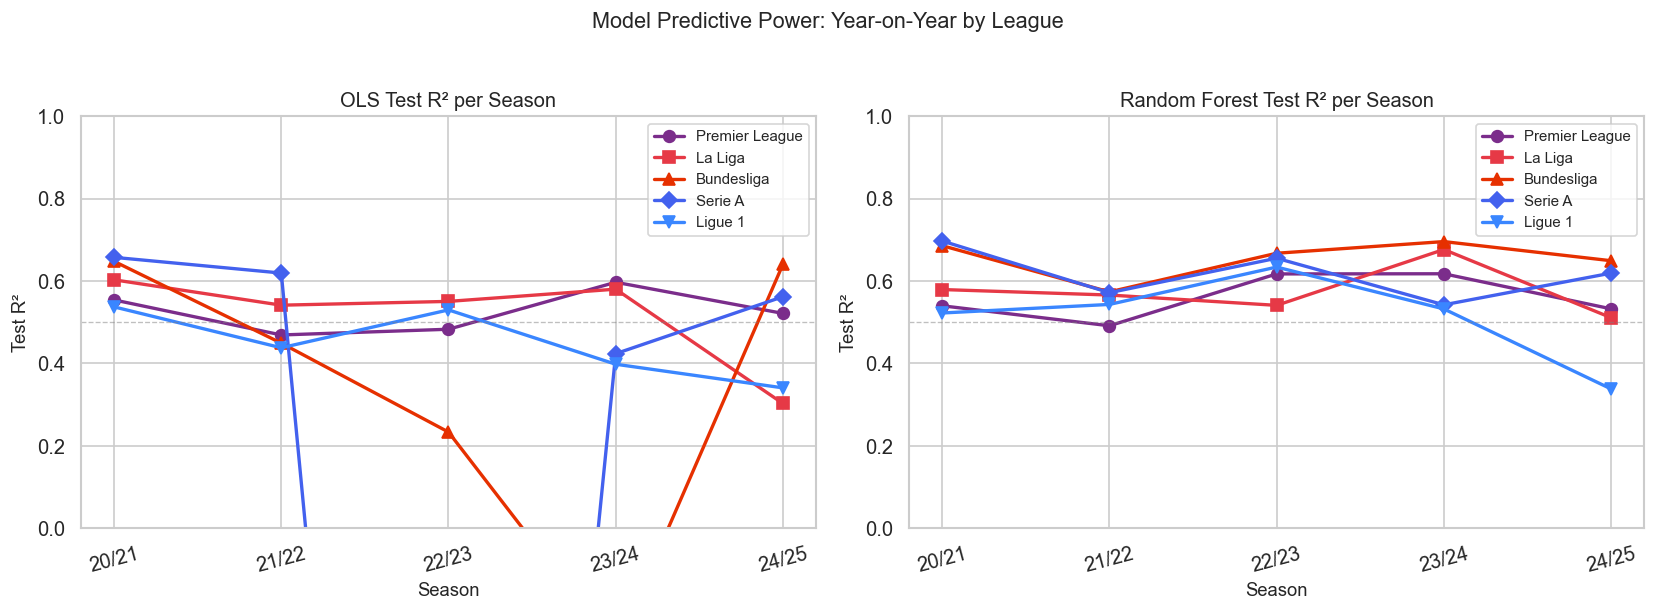

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for lg in LEAGUES:
    ols_r2s = [yoy[lg][s]['ols_r2'] if s in yoy[lg] else np.nan for s in SEASONS]
    rf_r2s  = [yoy[lg][s]['rf_r2']  if s in yoy[lg] else np.nan for s in SEASONS]
    axes[0].plot(SEASON_LABELS, ols_r2s, marker=lm[lg], color=lc[lg], linewidth=2, label=lg, markersize=7)
    axes[1].plot(SEASON_LABELS, rf_r2s,  marker=lm[lg], color=lc[lg], linewidth=2, label=lg, markersize=7)
for ax, title in zip(axes, ['OLS Test R² per Season', 'Random Forest Test R² per Season']):
    ax.set_xlabel('Season'); ax.set_ylabel('Test R²'); ax.set_title(title)
    ax.legend(fontsize=9); ax.set_ylim(0, 1); ax.tick_params(axis='x', rotation=15)
    ax.axhline(0.5, color='grey', lw=0.8, linestyle='--', alpha=0.5)
plt.suptitle('Model Predictive Power: Year-on-Year by League', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_PATH}/yoy_model_r2.png', bbox_inches='tight')
plt.show()


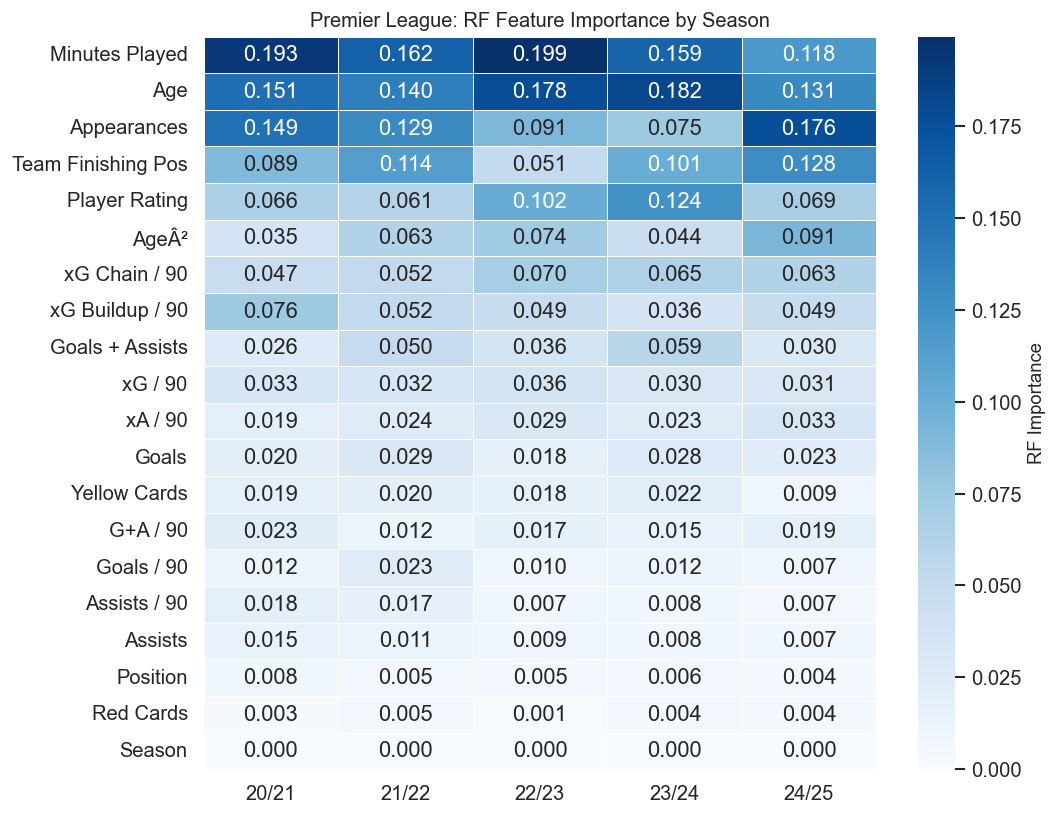

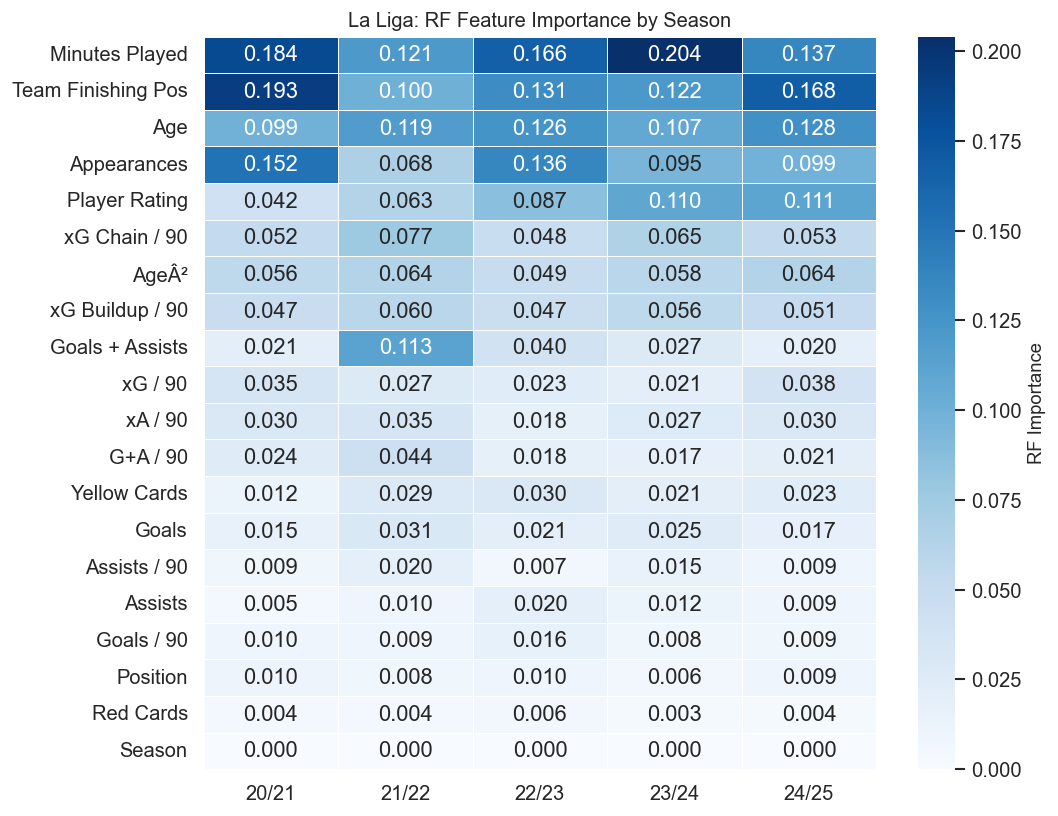

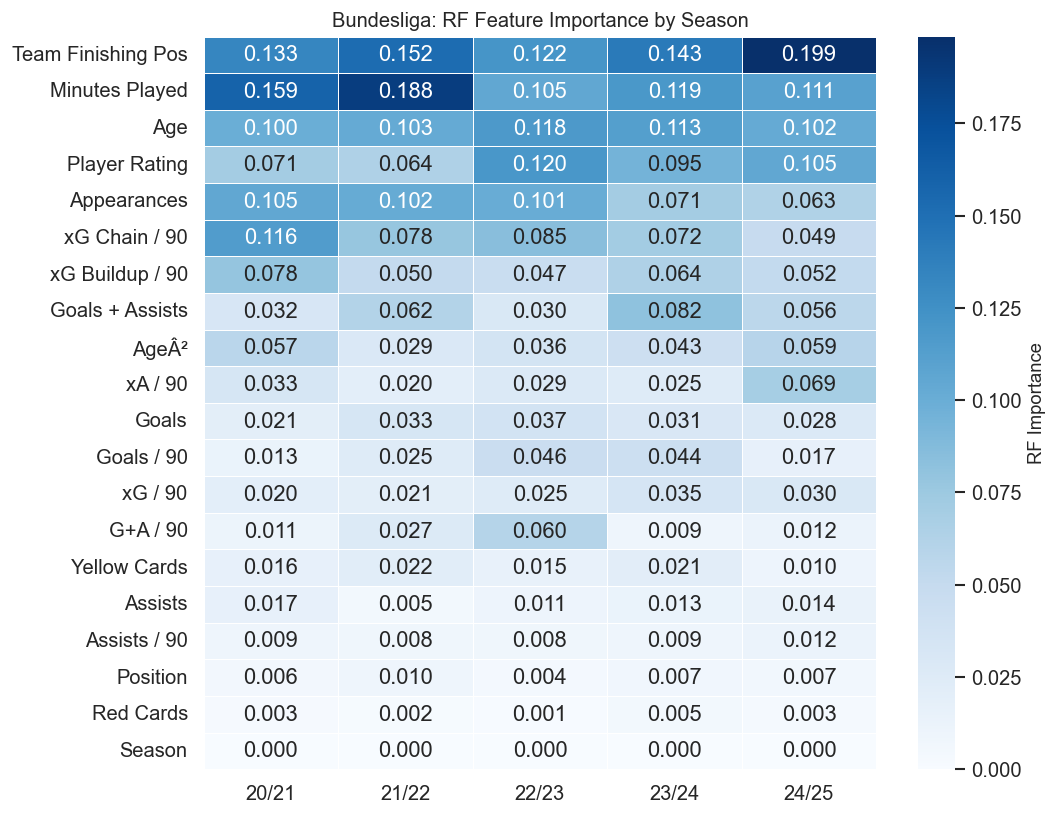

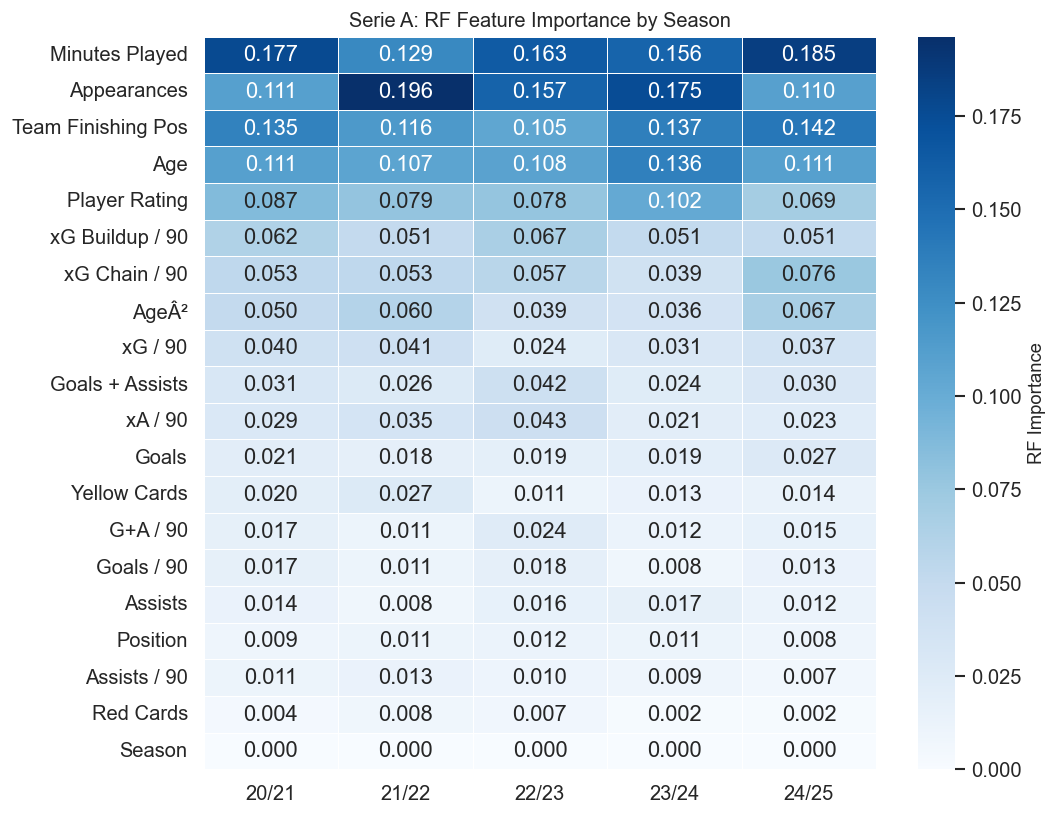

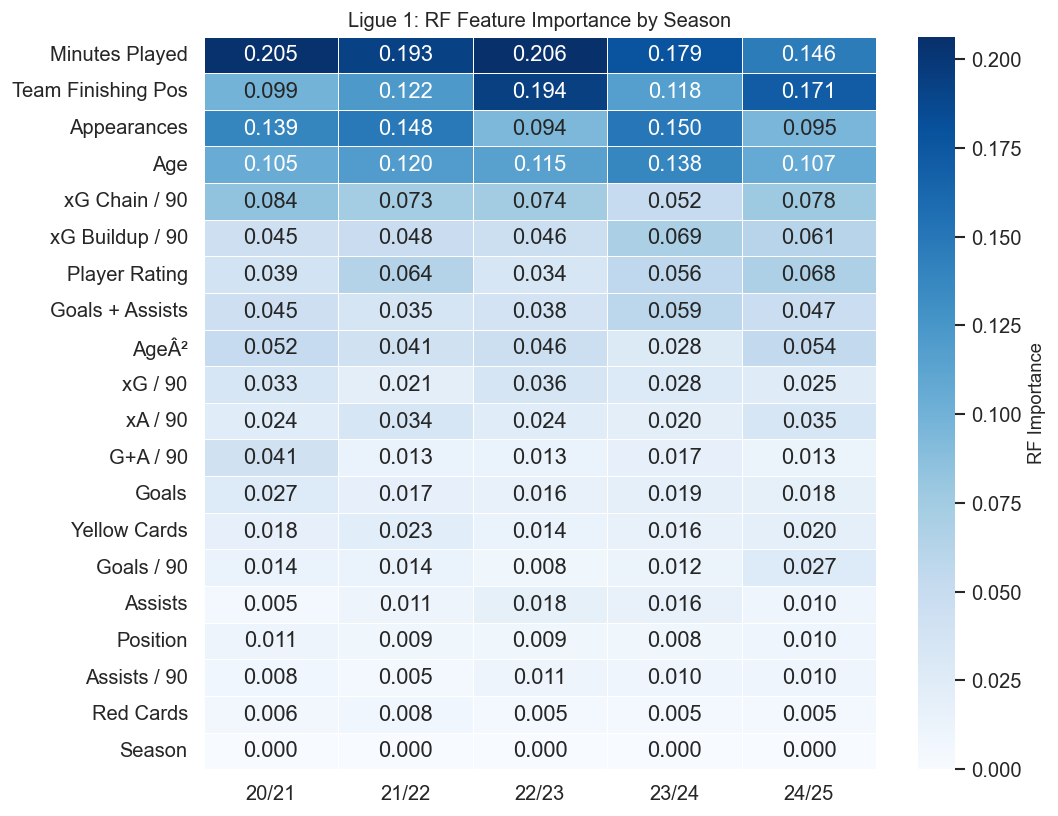

In [66]:
for lg in LEAGUES:
    mat = {}
    for season in SEASONS:
        if season not in yoy[lg]: continue
        imp = yoy[lg][season]['rf_imp']
        for fi, f in enumerate(PER_SEASON_FEATS):
            mat.setdefault(f, {})[SEASON_LABELS[SEASONS.index(season)]] = imp[fi]
    heat = pd.DataFrame(mat).T.fillna(0)
    heat = heat.loc[[f for f in PER_SEASON_FEATS if f in heat.index]]
    heat.index = [lbl(f) for f in heat.index]
    heat = heat.loc[heat.mean(axis=1).sort_values(ascending=False).index]
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(heat, annot=True, fmt='.3f', cmap='Blues', ax=ax,
                linewidths=0.4, cbar_kws={'label':'RF Importance'})
    ax.set_title(f'{lg}: RF Feature Importance by Season', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'{OUT_PATH}/yoy_rf_heatmap_{lg.lower().replace(" ","_")}.png', bbox_inches='tight')
    plt.show()


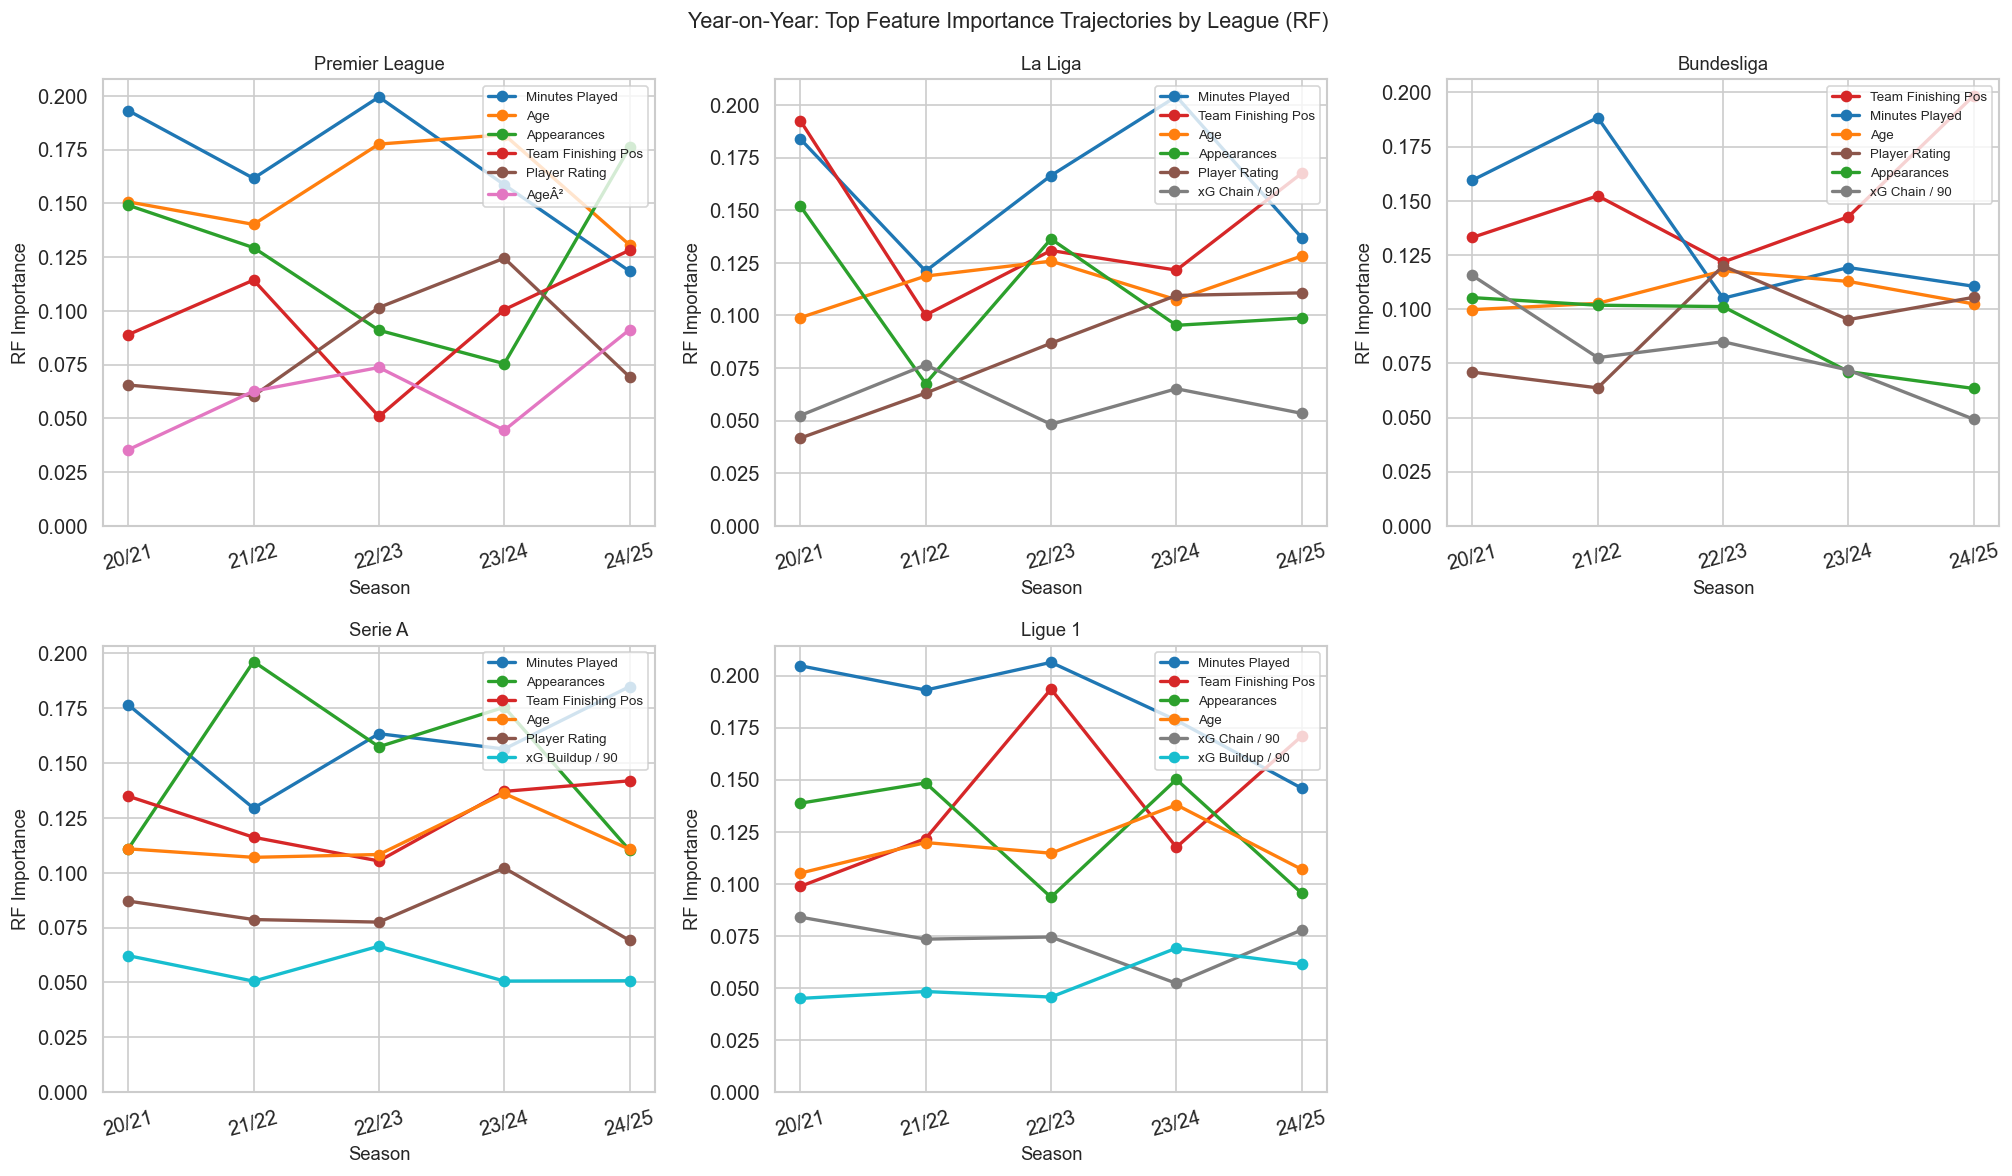

In [67]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
# Pre-compute top features per league, then build a global feature→color map
league_top_feats = {}
all_top_feats = []
for lg in list(LEAGUES.keys()):
    feat_mean = {}
    for f_idx, f in enumerate(PER_SEASON_FEATS):
        vals = [yoy[lg][s]['rf_imp'][f_idx] for s in SEASONS if s in yoy[lg]]
        feat_mean[f] = np.mean(vals) if vals else 0
    top = sorted(feat_mean, key=feat_mean.get, reverse=True)[:6]
    league_top_feats[lg] = top
    for f in top:
        if f not in all_top_feats:
            all_top_feats.append(f)

global_palette = plt.cm.tab10(np.linspace(0, 0.9, len(all_top_feats)))
feat_color = {f: global_palette[i] for i, f in enumerate(all_top_feats)}

for ax_idx, (lg, ax) in enumerate(zip(list(LEAGUES.keys()), axes.flatten())):
    for feat in league_top_feats[lg]:
        f_idx = PER_SEASON_FEATS.index(feat)
        imps  = [yoy[lg][s]['rf_imp'][f_idx] if s in yoy[lg] else np.nan for s in SEASONS]
        ax.plot(SEASON_LABELS, imps, marker='o', color=feat_color[feat], linewidth=2, label=lbl(feat), markersize=6)
    ax.set_title(f'{lg}', fontsize=11); ax.set_xlabel('Season'); ax.set_ylabel('RF Importance')
    ax.set_ylim(0, None); ax.tick_params(axis='x', rotation=15); ax.legend(fontsize=8, loc='upper right')
axes.flatten()[5].axis('off')
plt.suptitle('Year-on-Year: Top Feature Importance Trajectories by League (RF)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUT_PATH}/yoy_top_features.png', bbox_inches='tight')
plt.show()


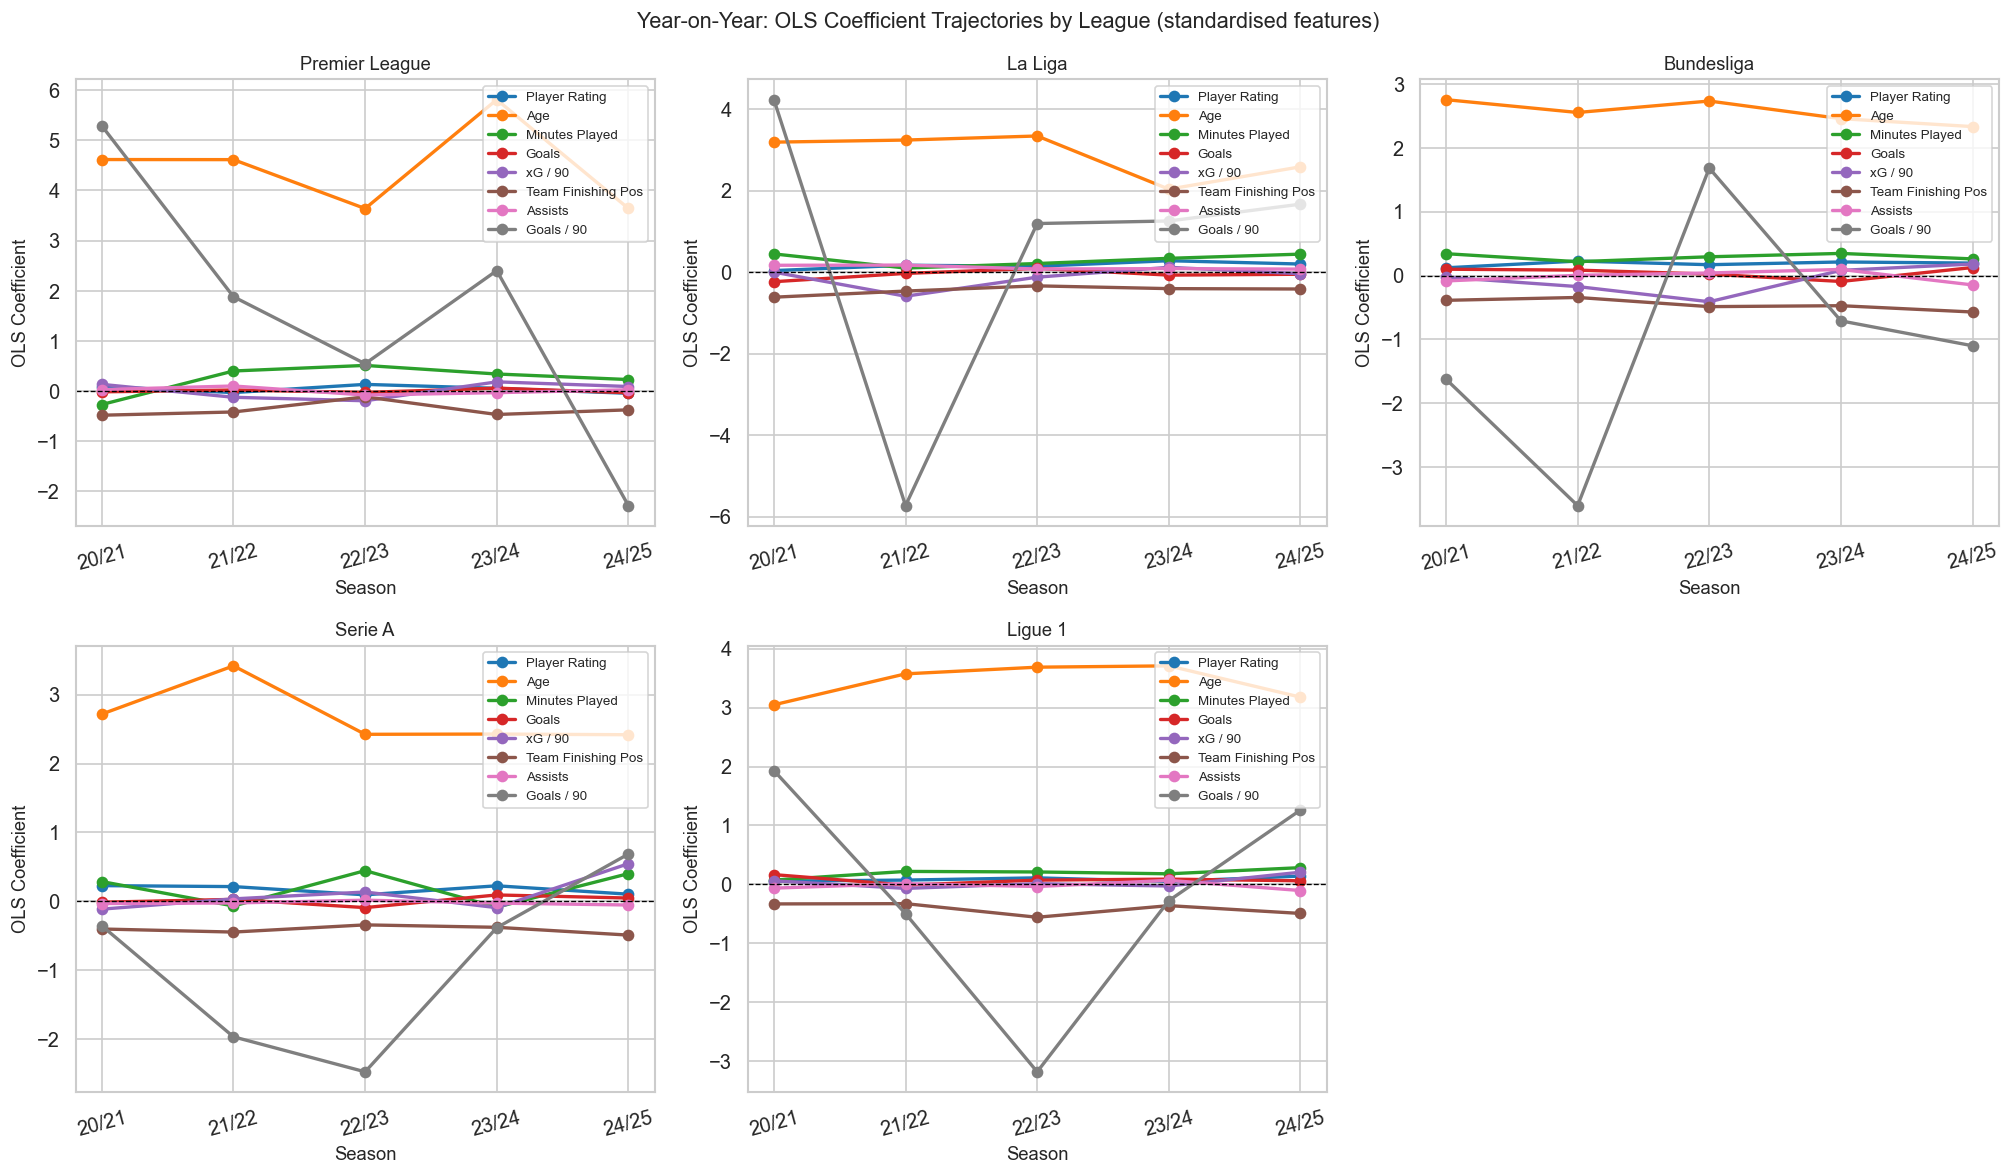

In [68]:
KEY_FEATS_YOY = ['rating_imp','Age','minutes','goals','xG90','team_finishing_pos','assists','Gls_90']
KEY_FEATS_YOY = [f for f in KEY_FEATS_YOY if f in PER_SEASON_FEATS]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
for ax, lg in zip(axes.flatten(), list(LEAGUES.keys())):
    palette = plt.cm.tab10(np.linspace(0, 0.75, len(KEY_FEATS_YOY)))
    for feat, col in zip(KEY_FEATS_YOY, palette):
        f_idx = PER_SEASON_FEATS.index(feat)
        coefs = [yoy[lg][s]['ols_coef'][f_idx] if s in yoy[lg] else np.nan for s in SEASONS]
        ax.plot(SEASON_LABELS, coefs, marker='o', color=col, linewidth=2, label=lbl(feat), markersize=6)
    ax.axhline(0, color='black', lw=0.8, linestyle='--')
    ax.set_title(f'{lg}', fontsize=11); ax.set_xlabel('Season'); ax.set_ylabel('OLS Coefficient')
    ax.tick_params(axis='x', rotation=15); ax.legend(fontsize=8, loc='upper right')
axes.flatten()[5].axis('off')
plt.suptitle('Year-on-Year: OLS Coefficient Trajectories by League (standardised features)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUT_PATH}/yoy_ols_coefs.png', bbox_inches='tight')
plt.show()


In [69]:
print('Year-on-Year RF R² by League')
print(f"{'League':<18}", end='')
for sl in SEASON_LABELS: print(f'  {sl:>7}', end='')
print('\n' + '-'*57)
for lg in LEAGUES:
    print(f'{lg:<18}', end='')
    for s in SEASONS:
        v = yoy[lg][s]['rf_r2'] if s in yoy[lg] else float('nan')
        print(f'  {v:>7.3f}', end='')
    print()

Year-on-Year RF R2 by League
League                20/21    21/22    22/23    23/24    24/25
---------------------------------------------------------
Premier League        0.540    0.491    0.617    0.618    0.533
La Liga               0.579    0.566    0.541    0.677    0.511
Bundesliga            0.686    0.574    0.668    0.696    0.649
Serie A               0.697    0.572    0.655    0.542    0.619
Ligue 1               0.522    0.543    0.634    0.532    0.338


## 13. Player Value Estimator

This section demonstrates how to predict the market value of a **hypothetical player** using the Ridge regression model trained on the full dataset.

Given a set of performance statistics and player attributes, the model:
1. Predicts a **point estimate** of market value (in euros)
2. Provides a **confidence range** using Â±1 training RMSE on the log scale
3. Finds the **most similar real player-season** via cosine similarity

This functionality is also available interactively on the dashboard's Value Estimator page.

In [70]:
ESTIMATOR_FEATS = [
    'Age', 'age_sq', 'pos_enc', 'league_enc',
    'Gls_90', 'Ast_90', 'xG90', 'xA90', 'xGChain90', 'xGBuildup90',
    'rating_imp', 'minutes', 'appearances', 'team_finishing_pos',
]

# Add league_enc if not present
if 'league_enc' not in df.columns:
    lenc = {'eng Premier League': 0, 'es La Liga': 1,
            'de Bundesliga': 2, 'it Serie A': 3, 'fr Ligue 1': 4}
    df['league_enc'] = df['league_comp'].map(lenc).fillna(2)

est_df = df.copy()
for c in ESTIMATOR_FEATS:
    if c in est_df.columns:
        est_df[c] = est_df[c].fillna(est_df[c].median())

mask = est_df['log_mv'].notna() & est_df[ESTIMATOR_FEATS].notna().all(axis=1)
X_est = est_df.loc[mask, ESTIMATOR_FEATS].values.astype(float)
y_est = est_df.loc[mask, 'log_mv'].values.astype(float)

mu_est  = X_est.mean(0)
sig_est = X_est.std(0) + 1e-9
Xn_est  = (X_est - mu_est) / sig_est

lam = 10.0
y_mean = y_est.mean()
y_c    = y_est - y_mean
w_est = np.linalg.solve(
    Xn_est.T @ Xn_est + lam * np.eye(len(mu_est)),
    Xn_est.T @ y_c
)

train_rmse = float(np.sqrt(np.mean((Xn_est @ w_est + y_mean - y_est) ** 2)))
train_r2   = r2(y_est, Xn_est @ w_est + y_mean)

print(f"Estimator Ridge model trained on {mask.sum():,} player-seasons")
print(f"Train R²: {train_r2:.3f}")
print(f"Train RMSE: {train_rmse:.4f}  (log scale)")
print(f"±1 RMSE confidence band covers roughly 68% of observations")

Estimator Ridge model trained on 12,938 player-seasons
Train R²: 0.546
Train RMSE: 1.0111  (log scale)
±1 RMSE confidence band covers roughly 68% of observations


In [71]:
hypothetical = {
    #Player profile
    'position': 'FW',
    'league':'Premier League',
    'Age': 24,
    'team_finishing_pos': 4,

    #Season statistics
    'appearances': 34,
    'minutes': 2900,
    'goals': 18,
    'assists': 7,

    # Advanced stats
    'xG90': 0.52,
    'xA90': 0.22,
    'xGChain90': 0.71,
    'xGBuildup90': 0.12,
    'rating_imp': 7.4,
}

# Encode categoricals
pos_enc_map  = {'GK': 0, 'DF': 1, 'MF': 2, 'FW': 3}
lg_enc_map   = {'Premier League': 0, 'La Liga': 1, 'Bundesliga': 2, 'Serie A': 3, 'Ligue 1': 4}

mins_90 = max(hypothetical['minutes'] / 90, 0.01)
gls_90 = hypothetical['goals'] / mins_90
ast_90 = hypothetical['assists'] / mins_90
age = hypothetical['Age']

x_input = np.array([[
    age, age ** 2,
    pos_enc_map[hypothetical['position']],
    lg_enc_map[hypothetical['league']],
    gls_90, ast_90,
    hypothetical['xG90'], hypothetical['xA90'],
    hypothetical['xGChain90'], hypothetical['xGBuildup90'],
    hypothetical['rating_imp'],
    hypothetical['minutes'], hypothetical['appearances'],
    hypothetical['team_finishing_pos'],
]], dtype=float)

# Predict
xn = (x_input - mu_est) / sig_est
log_pred = (xn @ w_est).item() + y_mean
mv_point = np.expm1(log_pred)
mv_low   = np.expm1(log_pred - train_rmse)
mv_high  = np.expm1(log_pred + train_rmse)

print(f"Hypothetical Player Profile")
print(f" Position: {hypothetical['position']}   League: {hypothetical['league']}")
print(f" Age: {age}    Team finish: {hypothetical['team_finishing_pos']}")
print(f" Goals: {hypothetical['goals']}   Assists: {hypothetical['assists']}")
print(f" xG/90: {hypothetical['xG90']}   xA/90  : {hypothetical['xA90']}")
print(f" Rating: {hypothetical['rating_imp']}")
print(f" Predicted Market Value: €{mv_point/1e6:.1f}M")
print(f" Estimated Range: €{mv_low/1e6:.1f}M  -  €{mv_high/1e6:.1f}M")
print(f" (±1 RMSE = {train_rmse:.3f} on log scale)")

Hypothetical Player Profile
 Position: FW   League: Premier League
 Age: 24    Team finish: 4
 Goals: 18   Assists: 7
 xG/90: 0.52   xA/90  : 0.22
 Rating: 7.4
 Predicted Market Value: €83.5M
 Estimated Range: €30.4M  -  €229.6M
 (±1 RMSE = 1.011 on log scale)


In [75]:
SIM_FEATS_EST = ['Age', 'Gls_90', 'Ast_90', 'xG90', 'xA90', 'xGChain90', 'xGBuildup90', 'rating_imp', 'minutes', 'team_finishing_pos']

pos_label_map = {'GK': 0, 'DF': 1, 'MF': 2, 'FW': 3}
inp_pos_enc   = pos_enc_map[hypothetical['position']]

# Filter to same position
sim_pool = est_df[est_df['pos_enc'] == inp_pos_enc].copy()
for c in SIM_FEATS_EST:
    sim_pool[c] = sim_pool[c].fillna(sim_pool[c].median())

X_sim = sim_pool[SIM_FEATS_EST].values.astype(float)
mu_s = X_sim.mean(0); sig_s = X_sim.std(0) + 1e-9
Xsim_n = (X_sim - mu_s) / sig_s

q = np.array([[age, gls_90, ast_90,
               hypothetical['xG90'], hypothetical['xA90'],
               hypothetical['xGChain90'], hypothetical['xGBuildup90'],
               hypothetical['rating_imp'],
               hypothetical['minutes'], hypothetical['team_finishing_pos']]])
q_n = (q - mu_s) / sig_s

# Cosine similarity
Xsim_nn = Xsim_n / (np.linalg.norm(Xsim_n, axis=1, keepdims=True) + 1e-9)
q_nn = q_n / (np.linalg.norm(q_n) + 1e-9)
sims = (Xsim_nn @ q_nn.T).flatten()

top5_idx = np.argsort(sims)[::-1][:5]

# Map league_comp back to readable name
lg_name_map = {'eng Premier League': 'Premier League', 'es La Liga': 'La Liga', 'de Bundesliga': 'Bundesliga', 'it Serie A': 'Serie A',
               'fr Ligue 1': 'Ligue 1'}
pos_str_map = {0: 'GK', 1: 'DF', 2: 'MF', 3: 'FW'}
season_lbl  = {'2020-2021':'20/21','2021-2022':'21/22','2022-2023':'22/23','2023-2024':'23/24','2024-2025':'24/25'}

print(f"Top 5 most similar real player-seasons to the hypothetical {hypothetical['position']}:")
print(f"  {'Player':<22} {'Club':<20} {'League':<16} {'Season':<7} {'MV (M)':>8}  {'Sim%':>5}")
for rank, idx in enumerate(top5_idx, 1):
    r = sim_pool.iloc[idx]
    name = r.get('name', 'Unknown')
    club = str(r.get('club', ''))[:18]
    lg = lg_name_map.get(r.get('league_comp', ''), str(r.get('league_comp', '')))[:14]
    szn = season_lbl.get(r.get('season', ''), str(r.get('season', '')))
    mv = r.get('market_value_end', float('nan'))
    mv_str = f"{mv/1e6:.1f}M" if mv == mv else 'N/A'
    sim_pct = int(sims[idx] * 100)
    print(f"  {name:<22} {club:<20} {lg:<16} {szn:<7} {mv_str:>8}   {sim_pct:>4}%")


Top 5 most similar real player-seasons to the hypothetical FW:
  Player                 Club                 League           Season    MV (M)   Sim%
  Jonathan David         Lille                Ligue 1          23/24      50.0M     98%
  Alexander Isak         Newcastle United     Premier League   24/25     100.0M     98%
  Tammy Abraham          Roma                 Serie A          21/22      45.0M     98%
  Erling Haaland         Manchester City      Premier League   24/25     200.0M     98%
  Ollie Watkins          Aston Villa          Premier League   23/24      65.0M     98%


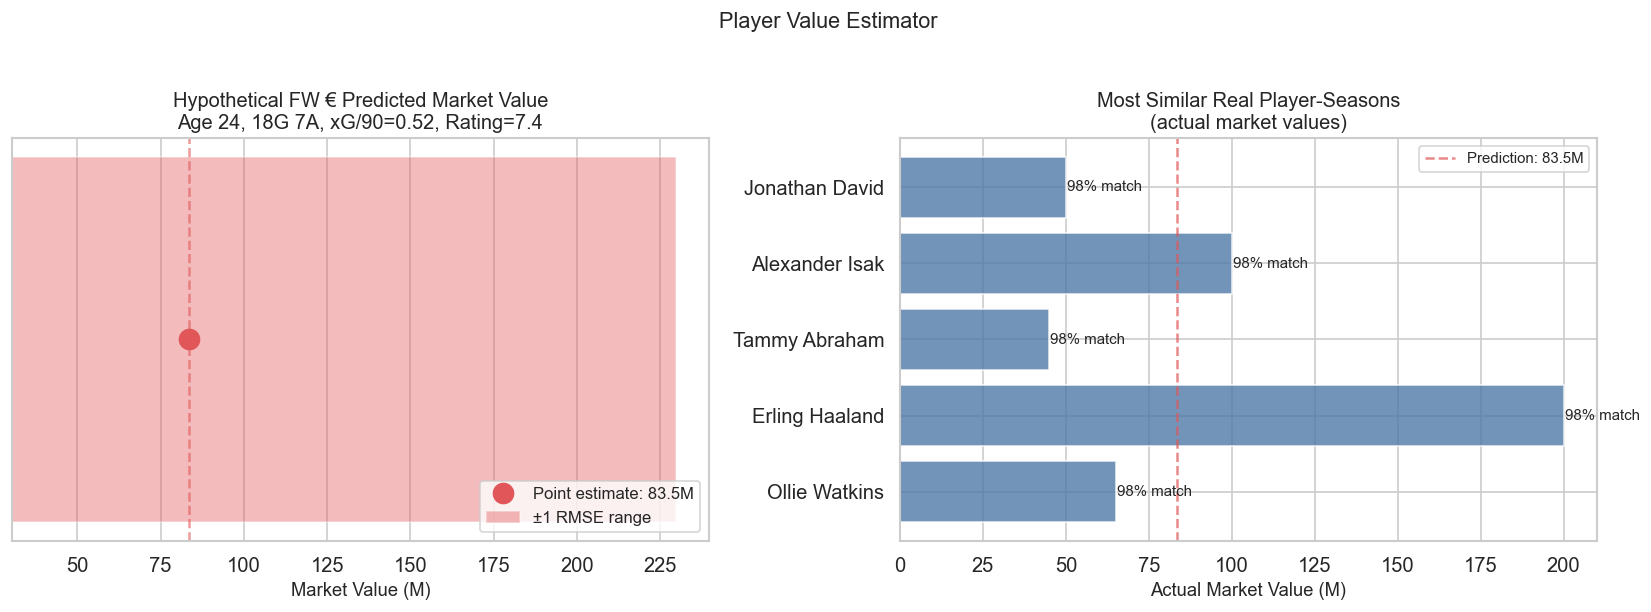

Saved value_estimator.png


In [77]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: predicted value with range
ax = axes[0]
ax.barh(['Estimated Range'], [mv_high/1e6 - mv_low/1e6],
        left=[mv_low/1e6], color='#e15759', alpha=0.4, height=0.4, label='±1 RMSE range')
ax.plot([mv_point/1e6], [0], 'o', color='#e15759', markersize=12, zorder=5,
        label=f'Point estimate: {mv_point/1e6:.1f}M')
ax.set_xlabel('Market Value (M)')
ax.set_title(f"Hypothetical {hypothetical['position']} Predicted Market Value\n"
             f"Age {age}, {hypothetical['goals']}G {hypothetical['assists']}A, "
             f"xG/90={hypothetical['xG90']}, Rating={hypothetical['rating_imp']}")
ax.legend(loc='lower right', fontsize=10)
ax.set_yticks([])
ax.axvline(mv_point/1e6, color='#e15759', lw=1.5, linestyle='--', alpha=0.6)

# Right: top-5 similar players' actual market values
ax2 = axes[1]
names = []
mvs = []
sims_ = []
for idx in top5_idx:
    r = sim_pool.iloc[idx]
    mv = r.get('market_value_end', float('nan'))
    if mv == mv:
        names.append(r.get('name', 'Unknown')[:20])
        mvs.append(mv / 1e6)
        sims_.append(int(sims[idx] * 100))

y_pos = np.arange(len(names))
bars = ax2.barh(y_pos, mvs, color='#4e79a7', alpha=0.8, edgecolor='white')
for bar, sim_p in zip(bars, sims_):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{sim_p}% match', va='center', fontsize=9)
ax2.axvline(mv_point/1e6, color='#e15759', lw=1.5, linestyle='--',
            alpha=0.7, label=f'Prediction: {mv_point/1e6:.1f}M')
ax2.set_yticks(y_pos); ax2.set_yticklabels(names)
ax2.set_xlabel('Actual Market Value (M)')
ax2.set_title('Most Similar Real Player-Seasons\n(actual market values)')
ax2.legend(fontsize=9)
ax2.invert_yaxis()

plt.suptitle('Player Value Estimator', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_PATH}/value_estimator.png', bbox_inches='tight')
plt.show()
print("Saved value_estimator.png")